# 연고관광 클러스터별 지역점수 편향 재검토

## 분석 목적과 범위

기존 지역점수와 상위 20개를 독립 재현하고, 도시형 지역 집중의 원인을
지표 방향, 중복, 규모효과, 후보 필터 순서로 나누어 확인한다. 단일
점수보다 **전환 잠재력(POT) × 공급 준비도(SUP)** 포트폴리오를 주 결과로
사용하고 여섯 점수안을 같은 후보 자격에서 비교한다.

- 분석 단위: 2023~2025년 국민여행조사 방문지역 기준 시군구 1행
- 연고 방문: CASE 2·3 여행이며 출생지나 법적 고향을 뜻하지 않음
- 후보 자격: 대안 비교에서는 `CASE 2 N≥30`으로 통일
- 인구감소지역: 점수 계산 뒤 필터링하고 89개 안에서 순위를 재계산
- 결과 해석: 정책 효과의 인과 추정이 아닌 탐색적 우선순위 진단

기존 노트북, 기존 출력물, 원본 데이터와 공개 `src` 인터페이스는
수정하지 않는다.

## 지표와 점수안

- `V`: CASE 2·3 가중 방문규모의 전국 백분위
- `R`: 전체 여행 중 CASE 2·3 비중의 전국 백분위
- `D50=0.5V+0.5R`, `D30=0.3V+0.7R`, `D0=R`
- `G`: CASE 2·3 중 CASE 3 비중의 전국 백분위
- `POT=0.6D30+0.4G`
- `SUP`: 현행 군집 가중치 중 물리적 공급지표만 재정규화하고
  N=50 보정 군집 구성비로 결합한 공급 준비도

수정안에서 `flex=max(A,T)`는 `0.5A+0.5T`로 바꾸며 `P·H·Q`는
후보 설명용 보조지표로만 남긴다. 시설 수와 밀도는 기본 50:50으로
결합한다.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    """현재 위치에서 프로젝트 루트를 찾는다.

    Args:
        start: 탐색을 시작할 경로.

    Returns:
        `src`와 `data` 디렉터리를 가진 프로젝트 루트.

    Raises:
        FileNotFoundError: 프로젝트 루트를 찾지 못한 경우.
    """
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.path import (  # noqa: E402
    FEATURES_BY_REGION_DIR,
    OUTPUTS_DIR,
    POP_DECLINE_DANGER_REGION_PATH,
    create_output_directories,
)
from src.visualization import (  # noqa: E402
    COLORS,
    PALETTE,
    apply_plot_style,
)

NOTEBOOK_FILENAME = (
    "260726_연고관광_클러스터별_지역점수.ipynb"
)
TOP_N = 20
MIN_CASE2_N = 30
BASE_SHRINKAGE_N = 50
BASE_COUNT_WEIGHT = 0.50
SCORE_TOLERANCE = 1e-8
EXECUTION_READY_WEIGHTS = {
    "D30": 0.36,
    "G": 0.24,
    "SUP": 0.40,
}
EXECUTION_READY_ALT_WEIGHTS = {
    "D30": 0.35,
    "G": 0.25,
    "SUP": 0.40,
}

REGION_KEYS = ["시도명", "시군구명"]
CLUSTER_LABELS = [
    "당일 C1",
    "당일 C2",
    "숙박 C1",
    "숙박 C2",
    "숙박 C3",
]
PLAN_NAMES = [
    "현행안",
    "규모중립안",
    "수요우선안",
    "전환우선안",
    "지원필요안",
    "실행준비안",
]
ADMIN_TYPE_ORDER = [
    "특별·광역시 자치구",
    "기타 시",
    "군",
    "기타",
]
PORTFOLIO_ORDER = [
    "즉시실행형",
    "기반보강형",
    "공급활용형",
    "관찰형",
]

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)
warnings.filterwarnings("ignore", category=FutureWarning)

FIGURES_DIR, TABLES_DIR = create_output_directories(NOTEBOOK_FILENAME)
print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"그림 저장 경로: {FIGURES_DIR}")
print(f"표 저장 경로: {TABLES_DIR}")

프로젝트 루트: C:\Users\ilove\OneDrive\Desktop\tourism_poster
그림 저장 경로: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures
표 저장 경로: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\tables


In [2]:
TRAVEL_FEATURE_PATH = (
    FEATURES_BY_REGION_DIR
    / "sigungu_all_trip_features_2023_2025.csv"
)
TOURISM_FEATURE_PATH = (
    FEATURES_BY_REGION_DIR / "sigungu_tourism_wide_table.csv"
)
TRANSPORT_FEATURE_PATH = (
    FEATURES_BY_REGION_DIR / "sigungu_transportation_wide_table.csv"
)
POPULATION_DECLINE_PATH = POP_DECLINE_DANGER_REGION_PATH

reference_candidates = sorted(
    OUTPUTS_DIR.glob(
        "260726_연고관광_클러스터별_지역점수_*/tables/"
        "regional_affinity_cluster_scores.csv"
    ),
    key=lambda path: path.stat().st_mtime,
)
if not reference_candidates:
    raise FileNotFoundError("현행 점수 저장표를 찾지 못했습니다.")
CURRENT_SCORE_REFERENCE_PATH = reference_candidates[-1]

input_paths = pd.Series(
    {
        "국민여행조사 지역 피처": TRAVEL_FEATURE_PATH,
        "관광·상권 피처": TOURISM_FEATURE_PATH,
        "교통 피처": TRANSPORT_FEATURE_PATH,
        "인구감소지역 목록": POPULATION_DECLINE_PATH,
        "현행 점수 검산표": CURRENT_SCORE_REFERENCE_PATH,
    },
    name="입력 경로",
)
display(input_paths.to_frame())

,입력 경로
국민여행조사 지역 피처,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
관광·상권 피처,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
교통 피처,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
인구감소지역 목록,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
현행 점수 검산표,C:\Users\ilove\OneDrive\Desktop\tourism_poster...


## 데이터 로드와 결합 품질

국민여행조사 전용 지역코드의 `시도명 + 시군구명` 체계를 기준으로
결합한다. 군위군은 기존 노트북과 같은 명시적 분석키 교차표
(`경상북도 → 대구광역시`)를 적용하며 원본 열은 보존한다.

In [3]:
travel_raw = pd.read_csv(TRAVEL_FEATURE_PATH)
tourism_raw = pd.read_csv(TOURISM_FEATURE_PATH)
transport_raw = pd.read_csv(TRANSPORT_FEATURE_PATH)
population_raw = pd.read_csv(
    POPULATION_DECLINE_PATH,
    encoding="utf-8-sig",
)
current_reference = pd.read_csv(CURRENT_SCORE_REFERENCE_PATH)

loaded_shapes = pd.DataFrame(
    {
        "행": [
            len(travel_raw),
            len(tourism_raw),
            len(transport_raw),
            len(population_raw),
            len(current_reference),
        ],
        "열": [
            travel_raw.shape[1],
            tourism_raw.shape[1],
            transport_raw.shape[1],
            population_raw.shape[1],
            current_reference.shape[1],
        ],
    },
    index=[
        "국민여행조사 지역 피처",
        "관광·상권 피처",
        "교통 피처",
        "인구감소지역",
        "현행 점수 검산표",
    ],
)
display(loaded_shapes)

,행,열
국민여행조사 지역 피처,229,57
관광·상권 피처,229,187
교통 피처,229,8
인구감소지역,89,2
현행 점수 검산표,229,53


In [4]:
POPULATION_SIDO_MAP = {
    "부산": "부산광역시",
    "대구": "대구광역시",
    "인천": "인천광역시",
    "경기": "경기도",
    "강원": "강원도",
    "충북": "충청북도",
    "충남": "충청남도",
    "전북": "전라북도",
    "전남": "전라남도",
    "경북": "경상북도",
    "경남": "경상남도",
}


def duplicate_key_count(frame: pd.DataFrame) -> int:
    """시도·시군구 복합키의 중복 행 수를 계산한다.

    Args:
        frame: 지역 복합키를 가진 데이터프레임.

    Returns:
        중복으로 표시된 행 수.
    """
    return int(frame.duplicated(REGION_KEYS, keep=False).sum())


def anti_join_keys(
    left: pd.DataFrame,
    right: pd.DataFrame,
) -> pd.DataFrame:
    """왼쪽 자료에만 있는 지역 복합키를 반환한다.

    Args:
        left: 기준 데이터프레임.
        right: 비교 데이터프레임.

    Returns:
        왼쪽에만 있는 고유 지역키.
    """
    return (
        left[REGION_KEYS]
        .drop_duplicates()
        .merge(
            right[REGION_KEYS].drop_duplicates(),
            on=REGION_KEYS,
            how="left",
            indicator=True,
            validate="one_to_one",
        )
        .loc[lambda frame: frame["_merge"].eq("left_only"), REGION_KEYS]
        .reset_index(drop=True)
    )


raw_travel_only = anti_join_keys(travel_raw, tourism_raw)
raw_tourism_only = anti_join_keys(tourism_raw, travel_raw)

travel = travel_raw.copy()
travel["조사_시도명"] = travel["시도명"]
gunwi_mask = (
    travel["시도명"].eq("경상북도")
    & travel["시군구명"].eq("군위군")
)
travel.loc[gunwi_mask, "시도명"] = "대구광역시"
travel["군위군_분석키_교차표적용"] = gunwi_mask

population = population_raw.rename(
    columns={"sigungu": "시군구명"}
).copy()
population["시도명"] = population["sido"].map(POPULATION_SIDO_MAP)
if population["시도명"].isna().any():
    raise ValueError("정의되지 않은 인구감소지역 시도 약칭이 있습니다.")

population_unmatched_before = anti_join_keys(population, tourism_raw)
for name, frame in {
    "국민여행조사": travel,
    "관광·상권": tourism_raw,
    "교통": transport_raw,
    "인구감소지역": population,
}.items():
    if duplicate_key_count(frame) != 0:
        raise ValueError(f"{name} 지역 복합키가 유일하지 않습니다.")

if not population_unmatched_before.empty:
    raise ValueError(
        "군위군 교차표 적용 뒤에도 인구감소지역 미매칭이 있습니다."
    )

regional = (
    travel.merge(
        tourism_raw,
        on=REGION_KEYS,
        how="left",
        validate="one_to_one",
    )
    .merge(
        transport_raw,
        on=REGION_KEYS,
        how="left",
        validate="one_to_one",
    )
    .merge(
        population[REGION_KEYS].assign(인구감소지역=True),
        on=REGION_KEYS,
        how="left",
        validate="one_to_one",
    )
)
regional["인구감소지역"] = (
    regional["인구감소지역"].fillna(False).astype(bool)
)
regional["지역명"] = (
    regional["시도명"] + " " + regional["시군구명"]
)


def classify_admin_type(row: pd.Series) -> str:
    """시도·시군구 명칭으로 행정유형을 분류한다.

    Args:
        row: `시도명`, `시군구명`을 가진 지역 행.

    Returns:
        네 행정유형 중 하나.
    """
    metro = row["시도명"].endswith(("특별시", "광역시"))
    if metro and row["시군구명"].endswith("구"):
        return "특별·광역시 자치구"
    if row["시군구명"].endswith("시"):
        return "기타 시"
    if row["시군구명"].endswith("군"):
        return "군"
    return "기타"


regional["행정유형"] = regional.apply(classify_admin_type, axis=1)
regional["행정유형"] = pd.Categorical(
    regional["행정유형"],
    categories=ADMIN_TYPE_ORDER,
    ordered=True,
)

join_summary = pd.Series(
    {
        "결합 행 수": len(regional),
        "복합키 중복 행": duplicate_key_count(regional),
        "결합 결과 결측 셀": int(regional.isna().sum().sum()),
        "교차표 적용 전 국민여행조사 단독 키": len(raw_travel_only),
        "교차표 적용 전 관광표 단독 키": len(raw_tourism_only),
        "군위군 교차표 적용 행": int(gunwi_mask.sum()),
        "인구감소지역 일치 수": int(regional["인구감소지역"].sum()),
    },
    name="관측값",
)
display(join_summary.to_frame())

C:\Users\ilove\AppData\Local\Temp\ipykernel_14508\2347347702.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  regional["지역명"] = (
C:\Users\ilove\AppData\Local\Temp\ipykernel_14508\2347347702.py:137: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  regional["행정유형"] = regional.apply(classify_admin_type, axis=1)


,관측값
결합 행 수,229
복합키 중복 행,0
결합 결과 결측 셀,0
교차표 적용 전 국민여행조사 단독 키,1
교차표 적용 전 관광표 단독 키,1
군위군 교차표 적용 행,1
인구감소지역 일치 수,89


## 현행 점수 독립 재현

동률 평균순위 기반 0~100 백분위, 현행 시설 수·밀도 50:50 결합,
`flex=max(A,T)`, 현행 클러스터 가중치와 N=50 군집 구성비 보정을
그대로 구현한다.

In [5]:
RAW_SHARE_COLUMNS = {
    "당일 C1": "군집당일여행 C1_구성비",
    "당일 C2": "군집당일여행 C2_구성비",
    "숙박 C1": "군집숙박여행 C1_구성비",
    "숙박 C2": "군집숙박여행 C2_구성비",
    "숙박 C3": "군집숙박여행 C3_구성비",
}
CLUSTER_SIZE_COLUMNS = {
    "당일 C1": "군집당일여행 C1_가중규모",
    "당일 C2": "군집당일여행 C2_가중규모",
    "숙박 C1": "군집숙박여행 C1_가중규모",
    "숙박 C2": "군집숙박여행 C2_가중규모",
    "숙박 C3": "군집숙박여행 C3_가중규모",
}


def percentile_score(values: pd.Series) -> pd.Series:
    """수치를 평균 동률 순위 기반 0~100점으로 변환한다.

    Args:
        values: 결측이 없는 수치형 지역 지표.

    Returns:
        원래 인덱스를 유지한 백분위 점수.

    Raises:
        ValueError: 결측·무한값이 있거나 지역이 2개 미만인 경우.
    """
    numeric = pd.to_numeric(values, errors="coerce")
    if numeric.isna().any() or not np.isfinite(numeric).all():
        raise ValueError(f"{values.name}에 결측 또는 무한값이 있습니다.")
    if len(numeric) < 2:
        raise ValueError("백분위 계산에는 지역이 2개 이상 필요합니다.")
    ranks = numeric.rank(method="average")
    return 100.0 * (ranks - 1.0) / (len(numeric) - 1.0)


def resource_score_parts(
    frame: pd.DataFrame,
    count_column: str,
    density_column: str | None = None,
) -> tuple[pd.Series, pd.Series]:
    """시설 수와 밀도의 백분위 점수를 각각 계산한다.

    Args:
        frame: 시설 수와 면적 열을 가진 지역 자료.
        count_column: 시설 수 열 이름.
        density_column: 사전 계산된 밀도 열. 없으면 면적으로 계산.

    Returns:
        시설 수 백분위와 밀도 백분위의 튜플.
    """
    count = frame[count_column]
    if density_column is None:
        density = count / frame["면적_km2"]
        density.name = f"{count_column}_면적당"
    else:
        density = frame[density_column]
    return percentile_score(count), percentile_score(density)


def combined_resource_score(
    frame: pd.DataFrame,
    count_column: str,
    density_column: str | None = None,
    count_weight: float = 0.50,
) -> pd.Series:
    """시설 수와 밀도 백분위를 지정 비중으로 결합한다.

    Args:
        frame: 시설 수와 면적 열을 가진 지역 자료.
        count_column: 시설 수 열 이름.
        density_column: 사전 계산된 밀도 열. 없으면 면적으로 계산.
        count_weight: 시설 수 점수의 비중.

    Returns:
        수·밀도 결합점수.
    """
    count_score, density_score = resource_score_parts(
        frame,
        count_column,
        density_column,
    )
    return (
        count_weight * count_score
        + (1.0 - count_weight) * density_score
    )


EXPERIENCE_RESOURCE_PAIRS = {
    "체험교육": ("관광지수_체험/교육", "관광지밀도_체험/교육"),
    "축제테마": ("관광지수_축제/테마", "관광지밀도_축제/테마"),
    "레저스포츠": (
        "관광지수_레저/스포츠",
        "관광지밀도_레저/스포츠",
    ),
    "휴양온천": ("관광지수_휴양/온천", "관광지밀도_휴양/온천"),
    "유원지오락": (
        "상권중분류수_유원지·오락(R104)",
        "상권중분류밀도_유원지·오락(R104)",
    ),
    "스포츠서비스": (
        "상권중분류수_스포츠 서비스(R103)",
        "상권중분류밀도_스포츠 서비스(R103)",
    ),
    "예술스포츠여가": (
        "관광대분류수_예술스포츠여가",
        "관광대분류밀도_예술스포츠여가",
    ),
}


def calculate_supply_indices(
    frame: pd.DataFrame,
    count_weight: float,
    flex_method: str,
) -> pd.DataFrame:
    """물리적 관광·상권·교통 공급 하위지수를 계산한다.

    Args:
        frame: 결합된 시군구 자료.
        count_weight: 시설 수 점수의 결합 비중.
        flex_method: `max` 또는 `mean`인 교통 유연성 결합 방식.

    Returns:
        공급 하위지수 데이터프레임.

    Raises:
        ValueError: 지원하지 않는 유연성 방식인 경우.
    """
    resource_scores = pd.DataFrame(
        {
            label: combined_resource_score(
                frame,
                count,
                density,
                count_weight,
            )
            for label, (count, density) in (
                EXPERIENCE_RESOURCE_PAIRS.items()
            )
        }
    )
    family_labels = ["체험교육", "축제테마", "유원지오락"]
    food = combined_resource_score(
        frame,
        "관광대분류수_음식점업",
        "관광대분류밀도_음식점업",
        count_weight,
    )
    lodging = combined_resource_score(
        frame,
        "관광대분류수_숙박업_기타제외",
        "관광대분류밀도_숙박업_기타제외",
        count_weight,
    )
    transit = (
        0.35
        * combined_resource_score(
            frame,
            "철도역수",
            count_weight=count_weight,
        )
        + 0.35
        * combined_resource_score(
            frame,
            "고속버스터미널수",
            count_weight=count_weight,
        )
        + 0.30
        * combined_resource_score(
            frame,
            "버스정류장수",
            count_weight=count_weight,
        )
    )
    road = combined_resource_score(
        frame,
        "고속도로출입시설수_IC",
        count_weight=count_weight,
    )
    solo = (
        0.30 * food
        + 0.25
        * combined_resource_score(
            frame,
            "상권중분류수_비알코올 (I212)",
            "상권중분류밀도_비알코올 (I212)",
            count_weight,
        )
        + 0.20
        * combined_resource_score(
            frame,
            "상권중분류수_종합 소매(G204)",
            "상권중분류밀도_종합 소매(G204)",
            count_weight,
        )
        + 0.15
        * combined_resource_score(
            frame,
            "상권중분류수_섬유·의복·신발 소매(G209)",
            "상권중분류밀도_섬유·의복·신발 소매(G209)",
            count_weight,
        )
        + 0.10
        * combined_resource_score(
            frame,
            "상권중분류수_주점(I211)",
            "상권중분류밀도_주점(I211)",
            count_weight,
        )
    )
    if flex_method == "max":
        flex = pd.concat([road, transit], axis=1).max(axis=1)
    elif flex_method == "mean":
        flex = 0.5 * road + 0.5 * transit
    else:
        raise ValueError(f"지원하지 않는 flex 방식: {flex_method}")

    return pd.DataFrame(
        {
            "E": resource_scores.mean(axis=1),
            "E_family": resource_scores[family_labels].mean(axis=1),
            "B": combined_resource_score(
                frame,
                "관광지수_총합",
                "관광지밀도_총합",
                count_weight,
            ),
            "F_food": food,
            "L": lodging,
            "T": transit,
            "A": road,
            "flex": flex,
            "C_solo": solo,
        },
        index=frame.index,
    )

In [6]:
visit_volume = percentile_score(
    regional["hometown_visit_weighted_all_trip_case23"]
)
visit_ratio = percentile_score(
    regional["hometown_visit_share_w_all_trip_case15_pct"]
)
case23_denom = (
    regional["CASE2_연고방문_관광포함"]
    + regional["CASE3_연고방문_관광미포함"]
)
conversion_need = percentile_score(
    regional["CASE3_연고방문_관광미포함"] / case23_denom
)
current_supply_indices = calculate_supply_indices(
    regional,
    count_weight=0.50,
    flex_method="max",
)
current_indices = current_supply_indices.copy()
current_indices.insert(0, "G", conversion_need)
current_indices.insert(0, "D", 0.5 * visit_volume + 0.5 * visit_ratio)
current_indices["P"] = percentile_score(
    100.0
    - regional["no_reservation_rate_w_rep_trip_case124_pct"]
)
current_indices["H"] = percentile_score(
    regional["activity_potential_rep_trip_case124_pct"]
)
current_indices["Q"] = (
    0.5
    * percentile_score(
        regional["revisit_intent_mean_w_rep_trip_case124"]
    )
    + 0.5
    * percentile_score(
        regional["satisfaction_mean_w_rep_trip_case124"]
    )
)

current_weight_table = pd.DataFrame(
    {
        "당일 C1": {
            "D": 0.20, "G": 0.15, "E": 0.30,
            "E_family": 0.10, "B": 0.00, "F_food": 0.00,
            "L": 0.00, "T": 0.00, "A": 0.00, "flex": 0.00,
            "C_solo": 0.00, "P": 0.15, "H": 0.05, "Q": 0.05,
        },
        "당일 C2": {
            "D": 0.30, "G": 0.25, "E": 0.00,
            "E_family": 0.00, "B": 0.20, "F_food": 0.10,
            "L": 0.00, "T": 0.00, "A": 0.00, "flex": 0.10,
            "C_solo": 0.00, "P": 0.00, "H": 0.00, "Q": 0.05,
        },
        "숙박 C1": {
            "D": 0.15, "G": 0.10, "E": 0.30,
            "E_family": 0.00, "B": 0.00, "F_food": 0.10,
            "L": 0.20, "T": 0.00, "A": 0.00, "flex": 0.05,
            "C_solo": 0.00, "P": 0.05, "H": 0.00, "Q": 0.05,
        },
        "숙박 C2": {
            "D": 0.20, "G": 0.10, "E": 0.00,
            "E_family": 0.00, "B": 0.05, "F_food": 0.00,
            "L": 0.10, "T": 0.30, "A": 0.00, "flex": 0.00,
            "C_solo": 0.20, "P": 0.00, "H": 0.00, "Q": 0.05,
        },
        "숙박 C3": {
            "D": 0.30, "G": 0.05, "E": 0.00,
            "E_family": 0.00, "B": 0.20, "F_food": 0.15,
            "L": 0.15, "T": 0.00, "A": 0.10, "flex": 0.00,
            "C_solo": 0.00, "P": 0.00, "H": 0.00, "Q": 0.05,
        },
    }
)

current_weight_sums = current_weight_table.sum(axis=0)
if not np.allclose(current_weight_sums, 1.0, atol=1e-12):
    raise ValueError("현행 클러스터 가중치 합이 1이 아닙니다.")

national_cluster_sizes = pd.Series(
    {
        label: regional[column].sum()
        for label, column in CLUSTER_SIZE_COLUMNS.items()
    }
)
national_cluster_priors = (
    national_cluster_sizes / national_cluster_sizes.sum()
)


def shrink_cluster_shares(
    frame: pd.DataFrame,
    threshold: int,
) -> pd.DataFrame:
    """지역 군집 구성비를 전국 구성비 쪽으로 수축한다.

    Args:
        frame: 군집 구성비와 CASE 2 표본 수를 가진 지역 자료.
        threshold: 구성비를 온전히 신뢰할 CASE 2 N 기준.

    Returns:
        클러스터명이 열인 보정 구성비 표.
    """
    reliability = (
        frame["case2_trip_n_all_trip_case15"] / threshold
    ).clip(upper=1.0)
    raw_shares = pd.DataFrame(
        {
            label: frame[column]
            for label, column in RAW_SHARE_COLUMNS.items()
        },
        index=frame.index,
    )
    shrunk = raw_shares.mul(reliability, axis=0).add(
        pd.DataFrame(
            np.outer(1.0 - reliability, national_cluster_priors),
            index=frame.index,
            columns=CLUSTER_LABELS,
        )
    )
    if not np.allclose(shrunk.sum(axis=1), 1.0, atol=1e-10):
        raise ValueError("보정 군집 구성비 합이 1이 아닙니다.")
    return shrunk


current_shares = shrink_cluster_shares(
    regional,
    BASE_SHRINKAGE_N,
)
current_cluster_scores = current_indices[
    current_weight_table.index
].dot(current_weight_table)
current_contributions = current_cluster_scores * current_shares
current_score = current_contributions.sum(axis=1)

current_result = regional[
    [
        "spot_code",
        "시도명",
        "시군구명",
        "지역명",
        "행정유형",
        "case2_trip_n_all_trip_case15",
        "rep_trip_n_case124",
        "is_reliable_rep_trip_case124",
        "인구감소지역",
    ]
].copy()
current_result["현행안"] = current_score
current_result["현행_전국순위"] = current_score.rank(
    method="min",
    ascending=False,
).astype(int)
reliable_mask = current_result["is_reliable_rep_trip_case124"]
current_result["현행_지원검토순위"] = np.nan
current_result.loc[reliable_mask, "현행_지원검토순위"] = (
    current_score.loc[reliable_mask].rank(
        method="min",
        ascending=False,
    )
)

reproduction = current_result.merge(
    current_reference[
        REGION_KEYS + ["최종점수", "지원검토_순위"]
    ],
    on=REGION_KEYS,
    how="left",
    validate="one_to_one",
)
reproduction["점수차"] = (
    reproduction["현행안"] - reproduction["최종점수"]
)
reproduction["지원순위일치"] = (
    reproduction["현행_지원검토순위"].fillna(-1)
    == reproduction["지원검토_순위"].fillna(-1)
)
max_reproduction_error = reproduction["점수차"].abs().max()
print("현행 저장표와 독립 재계산 결과를 검산한다.")
display(
    pd.Series(
        {
            "최대 점수 절대오차": max_reproduction_error,
            "지원순위 불일치 지역": int(
                (~reproduction["지원순위일치"]).sum()
            ),
        },
        name="관측값",
    ).to_frame()
)

현행 저장표와 독립 재계산 결과를 검산한다.


,관측값
최대 점수 절대오차,0.000
지원순위 불일치 지역,0.000


## 편향 진단

현행 지원검토 상위 20개에서 지표군별 기여도, 수요의 절대규모 성분,
시설 수·밀도 차이, `max(A,T)` 상승분, 중첩 공급지표, 보조지표와
후보 필터 불일치를 각각 수치로 확인한다.

In [7]:
component_contributions = {}
for index_name in current_weight_table.index:
    weighted_share = current_shares.mul(
        current_weight_table.loc[index_name],
        axis=1,
    ).sum(axis=1)
    component_contributions[index_name] = (
        current_indices[index_name] * weighted_share
    )
component_contributions = pd.DataFrame(component_contributions)

contribution_groups = pd.DataFrame(
    {
        "수요 D": component_contributions["D"],
        "전환 G": component_contributions["G"],
        "공급": component_contributions[
            [
                "E", "E_family", "B", "F_food", "L",
                "T", "A", "flex", "C_solo",
            ]
        ].sum(axis=1),
        "대표여행 P·H·Q": component_contributions[
            ["P", "H", "Q"]
        ].sum(axis=1),
    }
)
if not np.allclose(
    contribution_groups.sum(axis=1),
    current_score,
    atol=1e-10,
):
    raise ValueError("현행 지표군 기여도의 합이 최종점수와 다릅니다.")

current_top20_mask = current_result["현행_지원검토순위"].le(TOP_N)
current_top20 = current_result.loc[current_top20_mask].copy()
current_top20_contributions = pd.concat(
    [
        current_top20[
            [
                "지역명", "행정유형", "인구감소지역",
                "case2_trip_n_all_trip_case15",
                "현행안", "현행_지원검토순위",
            ]
        ],
        contribution_groups.loc[current_top20_mask],
    ],
    axis=1,
).sort_values("현행_지원검토순위")

d_weight_factor = current_shares.mul(
    current_weight_table.loc["D"],
    axis=1,
).sum(axis=1)
demand_scale_contribution = 0.5 * visit_volume * d_weight_factor
demand_ratio_contribution = 0.5 * visit_ratio * d_weight_factor

facility_pairs = list(EXPERIENCE_RESOURCE_PAIRS.values()) + [
    ("관광지수_총합", "관광지밀도_총합"),
    ("관광대분류수_음식점업", "관광대분류밀도_음식점업"),
    (
        "관광대분류수_숙박업_기타제외",
        "관광대분류밀도_숙박업_기타제외",
    ),
    ("철도역수", None),
    ("고속버스터미널수", None),
    ("버스정류장수", None),
    ("고속도로출입시설수_IC", None),
]
facility_count_scores = []
facility_density_scores = []
for count_column, density_column in facility_pairs:
    count_part, density_part = resource_score_parts(
        regional,
        count_column,
        density_column,
    )
    facility_count_scores.append(count_part)
    facility_density_scores.append(density_part)
facility_audit = regional[
    ["지역명", "행정유형"]
].copy()
facility_audit["평균_시설수_백분위"] = pd.concat(
    facility_count_scores,
    axis=1,
).mean(axis=1)
facility_audit["평균_시설밀도_백분위"] = pd.concat(
    facility_density_scores,
    axis=1,
).mean(axis=1)
facility_admin_summary = (
    facility_audit.groupby("행정유형", observed=False)[
        ["평균_시설수_백분위", "평균_시설밀도_백분위"]
    ]
    .mean()
    .reset_index()
)

flex_uplift = (
    current_supply_indices["flex"]
    - 0.5
    * (
        current_supply_indices["A"]
        + current_supply_indices["T"]
    )
)
overlap_correlation = current_supply_indices[
    ["E", "E_family", "B"]
].corr(method="spearman")

current_bias_metrics = pd.DataFrame(
    [
        {
            "진단": "현행 상위 20개 인구감소지역 수",
            "관측값": int(current_top20["인구감소지역"].sum()),
            "해석단위": "개",
        },
        {
            "진단": "현행 상위 20개 특별·광역시 자치구 수",
            "관측값": int(
                current_top20["행정유형"]
                .eq("특별·광역시 자치구")
                .sum()
            ),
            "해석단위": "개",
        },
        {
            "진단": "현행 상위 20개 CASE 2 N<30 수",
            "관측값": int(
                current_top20[
                    "case2_trip_n_all_trip_case15"
                ].lt(MIN_CASE2_N).sum()
            ),
            "해석단위": "개",
        },
        {
            "진단": "현행 상위 20개 D 중 절대규모 기여 비중",
            "관측값": (
                demand_scale_contribution.loc[current_top20_mask].sum()
                / (
                    demand_scale_contribution.loc[
                        current_top20_mask
                    ].sum()
                    + demand_ratio_contribution.loc[
                        current_top20_mask
                    ].sum()
                )
            ),
            "해석단위": "비율",
        },
        {
            "진단": "현행 상위 20개 flex max 상승분 평균",
            "관측값": flex_uplift.loc[current_top20_mask].mean(),
            "해석단위": "점",
        },
        {
            "진단": "E-E_family Spearman 상관",
            "관측값": overlap_correlation.loc["E", "E_family"],
            "해석단위": "상관계수",
        },
        {
            "진단": "E-B Spearman 상관",
            "관측값": overlap_correlation.loc["E", "B"],
            "해석단위": "상관계수",
        },
        {
            "진단": "현행 상위 20개 P·H·Q 평균 기여도",
            "관측값": contribution_groups.loc[
                current_top20_mask,
                "대표여행 P·H·Q",
            ].mean(),
            "해석단위": "점",
        },
        {
            "진단": "현행 민감도에서 전체 229개 후보 사용",
            "관측값": len(regional),
            "해석단위": "개",
        },
    ]
)

admin_score_summary = (
    current_result.groupby("행정유형", observed=False)
    .agg(
        지역수=("지역명", "size"),
        현행점수_평균=("현행안", "mean"),
        현행점수_중앙값=("현행안", "median"),
    )
    .reset_index()
)
top20_admin = (
    current_top20.groupby("행정유형", observed=False)
    .size()
    .rename("현행상위20_지역수")
    .reset_index()
)
admin_score_summary = admin_score_summary.merge(
    top20_admin,
    on="행정유형",
    how="left",
    validate="one_to_one",
)
admin_score_summary["현행상위20_비중"] = (
    admin_score_summary["현행상위20_지역수"] / TOP_N
)

display(current_bias_metrics)
display(facility_admin_summary.round(2))
display(admin_score_summary.round(3))

,진단,관측값,해석단위
0,현행 상위 20개 인구감소지역 수,0.000,개
1,현행 상위 20개 특별·광역시 자치구 수,11.000,개
2,현행 상위 20개 CASE 2 N<30 수,4.000,개
3,현행 상위 20개 D 중 절대규모 기여 비중,0.478,비율
4,현행 상위 20개 flex max 상승분 평균,14.965,점
5,E-E_family Spearman 상관,0.902,상관계수
6,E-B Spearman 상관,0.193,상관계수
7,현행 상위 20개 P·H·Q 평균 기여도,2.951,점
8,현행 민감도에서 전체 229개 후보 사용,229.000,개


,행정유형,평균_시설수_백분위,평균_시설밀도_백분위
0,특별·광역시 자치구,48.460,61.490
1,기타 시,60.250,53.220
2,군,41.550,37.270
3,기타,NaN,NaN


,행정유형,지역수,현행점수_평균,현행점수_중앙값,현행상위20_지역수,현행상위20_비중
0,특별·광역시 자치구,69,56.465,57.293,11,0.550
1,기타 시,78,55.731,56.608,9,0.450
2,군,82,41.212,42.039,0,0.000
3,기타,0,NaN,NaN,0,0.000


## 공통 지표 재구성과 공급 준비도

공급 준비도는 현행 군집 가중치에서 `D·G·P·H·Q`를 제외하고 공급
하위지수만 군집별 합이 1이 되도록 재정규화한다. 수정 `flex`와 N=50
보정 구성비를 적용해 다섯 군집 공급점수를 결합한다.

In [8]:
modified_supply_indices = calculate_supply_indices(
    regional,
    count_weight=BASE_COUNT_WEIGHT,
    flex_method="mean",
)
supply_index_names = list(modified_supply_indices.columns)
supply_weight_table = current_weight_table.loc[
    supply_index_names
].copy()
supply_weight_table = supply_weight_table.div(
    supply_weight_table.sum(axis=0),
    axis=1,
)
supply_weight_sums = supply_weight_table.sum(axis=0)
if not np.allclose(supply_weight_sums, 1.0, atol=1e-12):
    raise ValueError("공급 가중치 재정규화 합이 1이 아닙니다.")


def calculate_supply_readiness(
    count_weight: float,
    shrinkage_n: int,
) -> tuple[pd.Series, pd.DataFrame]:
    """시설 결합비와 구성비 보정 기준으로 공급 준비도를 계산한다.

    Args:
        count_weight: 시설 수 백분위의 결합 비중.
        shrinkage_n: 군집 구성비 보정 기준 CASE 2 N.

    Returns:
        공급 준비도와 군집별 공급 기여도.
    """
    indices = calculate_supply_indices(
        regional,
        count_weight=count_weight,
        flex_method="mean",
    )
    cluster_supply = indices.dot(supply_weight_table)
    shares = shrink_cluster_shares(regional, shrinkage_n)
    contributions = cluster_supply * shares
    return contributions.sum(axis=1), contributions


supply_readiness, supply_contributions = (
    calculate_supply_readiness(
        BASE_COUNT_WEIGHT,
        BASE_SHRINKAGE_N,
    )
)
indicators = pd.DataFrame(
    {
        "V": visit_volume,
        "R": visit_ratio,
        "D50": 0.5 * visit_volume + 0.5 * visit_ratio,
        "D30": 0.3 * visit_volume + 0.7 * visit_ratio,
        "D0": visit_ratio,
        "G": conversion_need,
        "SUP": supply_readiness,
        "P": current_indices["P"],
        "H": current_indices["H"],
        "Q": current_indices["Q"],
    }
)
indicators["POT"] = (
    0.6 * indicators["D30"] + 0.4 * indicators["G"]
)
indicators["주요_공급군집"] = supply_contributions.idxmax(axis=1)

indicator_ranges = indicators[
    ["V", "R", "D50", "D30", "D0", "G", "POT", "SUP"]
].agg(["min", "mean", "max"]).T
display(indicator_ranges.round(2))
display(
    pd.concat(
        [
            supply_weight_table,
            supply_weight_sums.to_frame().T.rename(index={0: "합계"}),
        ]
    ).style.format("{:.3f}")
)

,min,mean,max
V,0.000,50.000,100.000
R,0.000,50.000,100.000
D50,0.000,50.000,93.860
D30,0.000,50.000,94.210
D0,0.000,50.000,100.000
G,0.000,50.000,100.000
POT,0.180,50.000,94.950
SUP,17.780,49.910,80.780


,당일 C1,당일 C2,숙박 C1,숙박 C2,숙박 C3
E,0.750,0.000,0.462,0.000,0.000
E_family,0.250,0.000,0.000,0.000,0.000
B,0.000,0.500,0.000,0.077,0.333
F_food,0.000,0.250,0.154,0.000,0.250
L,0.000,0.000,0.308,0.154,0.250
T,0.000,0.000,0.000,0.462,0.000
A,0.000,0.000,0.000,0.000,0.167
flex,0.000,0.250,0.077,0.000,0.000
C_solo,0.000,0.000,0.000,0.308,0.000
합계,1.000,1.000,1.000,1.000,1.000


## 대표 6개 점수안과 2축 포트폴리오

여섯 점수안의 순위·상위 20개는 모두 `CASE 2 N≥30`인 같은 지역에서
계산한다. 포트폴리오는 이 후보군의 POT·SUP 중앙값으로 네 유형을
구분한다.

In [9]:
score_plans = pd.DataFrame(
    {
        "현행안": current_score,
        "규모중립안": (
            0.60
            * (0.6 * indicators["D0"] + 0.4 * indicators["G"])
            + 0.40 * indicators["SUP"]
        ),
        "수요우선안": (
            0.70 * indicators["D30"]
            + 0.15 * indicators["G"]
            + 0.15 * indicators["SUP"]
        ),
        "전환우선안": (
            0.30 * indicators["D30"]
            + 0.50 * indicators["G"]
            + 0.20 * indicators["SUP"]
        ),
        "지원필요안": (
            0.60 * indicators["POT"]
            + 0.40 * (100.0 - indicators["SUP"])
        ),
        "실행준비안": sum(
            weight * indicators[column]
            for column, weight in (
                EXECUTION_READY_WEIGHTS.items()
            )
        ),
    }
)
eligible_mask = regional[
    "case2_trip_n_all_trip_case15"
].ge(MIN_CASE2_N)
eligible_count = int(eligible_mask.sum())

score_ranks = pd.DataFrame(index=regional.index)
for plan in PLAN_NAMES:
    score_ranks[f"{plan}_순위"] = np.nan
    score_ranks.loc[eligible_mask, f"{plan}_순위"] = (
        score_plans.loc[eligible_mask, plan].rank(
            method="min",
            ascending=False,
        )
    )

pot_median = indicators.loc[eligible_mask, "POT"].median()
sup_median = indicators.loc[eligible_mask, "SUP"].median()


def classify_portfolio(
    potential: pd.Series,
    supply: pd.Series,
    potential_cutoff: float,
    supply_cutoff: float,
) -> pd.Series:
    """전환 잠재력과 공급 준비도로 포트폴리오 유형을 나눈다.

    Args:
        potential: 전환 잠재력 점수.
        supply: 공급 준비도 점수.
        potential_cutoff: 잠재력 상·하 구분값.
        supply_cutoff: 공급 상·하 구분값.

    Returns:
        네 포트폴리오 유형의 시리즈.
    """
    conditions = [
        potential.ge(potential_cutoff)
        & supply.ge(supply_cutoff),
        potential.ge(potential_cutoff)
        & supply.lt(supply_cutoff),
        potential.lt(potential_cutoff)
        & supply.ge(supply_cutoff),
    ]
    choices = ["즉시실행형", "기반보강형", "공급활용형"]
    return pd.Series(
        np.select(conditions, choices, default="관찰형"),
        index=potential.index,
        dtype="object",
    )


portfolio_type = classify_portfolio(
    indicators["POT"],
    indicators["SUP"],
    pot_median,
    sup_median,
)
portfolio_type = pd.Categorical(
    portfolio_type,
    categories=PORTFOLIO_ORDER,
    ordered=True,
)

regional_scores = pd.concat(
    [
        regional[
            [
                "spot_code", "시도명", "시군구명", "지역명",
                "행정유형", "case2_trip_n_all_trip_case15",
                "rep_trip_n_case124",
                "is_reliable_rep_trip_case124",
                "인구감소지역",
            ]
        ],
        indicators,
        score_plans,
        score_ranks,
    ],
    axis=1,
)
regional_scores["후보자격_CASE2_N30"] = eligible_mask
regional_scores["포트폴리오유형"] = portfolio_type

top20_rows = []
top20_sets = {}
for plan in PLAN_NAMES:
    plan_top = (
        regional_scores.loc[
            eligible_mask,
            [
                "시도명", "시군구명", "지역명", "행정유형",
                "인구감소지역", "case2_trip_n_all_trip_case15",
                "포트폴리오유형", "POT", "SUP",
                "주요_공급군집", plan, f"{plan}_순위",
            ],
        ]
        .nsmallest(TOP_N, f"{plan}_순위")
        .copy()
    )
    plan_top.insert(0, "점수안", plan)
    plan_top = plan_top.rename(
        columns={plan: "점수", f"{plan}_순위": "순위"}
    )
    top20_rows.append(plan_top)
    top20_sets[plan] = set(plan_top["지역명"])
plan_top20 = pd.concat(top20_rows, ignore_index=True)

rank_correlation = score_plans.loc[
    eligible_mask,
    PLAN_NAMES,
].corr(method="spearman")
top20_intersection = pd.DataFrame(
    {
        left: {
            right: len(top20_sets[left] & top20_sets[right])
            for right in PLAN_NAMES
        }
        for left in PLAN_NAMES
    }
).loc[PLAN_NAMES, PLAN_NAMES]

admin_composition = (
    plan_top20.groupby(
        ["점수안", "행정유형"],
        observed=False,
    )
    .size()
    .rename("지역수")
    .reset_index()
)
admin_composition["비중"] = admin_composition["지역수"] / TOP_N
decline_composition = (
    plan_top20.groupby("점수안", observed=False)
    .agg(
        인구감소지역수=("인구감소지역", "sum"),
        인구감소지역비중=("인구감소지역", "mean"),
    )
    .reset_index()
)

portfolio_summary = (
    regional_scores.loc[eligible_mask]
    .groupby("포트폴리오유형", observed=False)
    .agg(
        지역수=("지역명", "size"),
        POT_중앙값=("POT", "median"),
        SUP_중앙값=("SUP", "median"),
        인구감소지역수=("인구감소지역", "sum"),
    )
    .reset_index()
)

print(f"공통 후보 자격 지역 수: {eligible_count}")
print(f"POT 중앙값: {pot_median:.2f}, SUP 중앙값: {sup_median:.2f}")
display(portfolio_summary.round(2))
display(decline_composition)
display(rank_correlation.round(3))

공통 후보 자격 지역 수: 163
POT 중앙값: 45.87, SUP 중앙값: 51.74


,포트폴리오유형,지역수,POT_중앙값,SUP_중앙값,인구감소지역수
0,즉시실행형,45,68.610,60.830,3
1,기반보강형,37,56.360,40.220,18
2,공급활용형,37,27.800,61.810,9
3,관찰형,44,31.860,42.610,35


,점수안,인구감소지역수,인구감소지역비중
0,규모중립안,0,0.000
1,수요우선안,0,0.000
2,실행준비안,0,0.000
3,전환우선안,0,0.000
4,지원필요안,3,0.150
5,현행안,0,0.000


,현행안,규모중립안,수요우선안,전환우선안,지원필요안,실행준비안
현행안,1.000,0.775,0.745,0.711,0.345,0.879
규모중립안,0.775,1.000,0.948,0.949,0.775,0.971
수요우선안,0.745,0.948,1.000,0.904,0.835,0.945
전환우선안,0.711,0.949,0.904,1.000,0.840,0.938
지원필요안,0.345,0.775,0.835,0.840,1.000,0.702
실행준비안,0.879,0.971,0.945,0.938,0.702,1.000


## 한 요인 민감도

실행준비안(`0.6POT+0.4SUP`)을 기준으로 수요의 절대규모 비중,
시설 수:밀도 비중, 군집 구성비 보정 N을 한 번에 하나씩 바꾼다.
같은 `CASE 2 N≥30` 후보군에서 순위상관, 상위 20개 교집합과
포트폴리오 유형 유지율을 계산한다.

In [10]:
sensitivity_specs = [
    {
        "시나리오": "기준_D30_수50밀50_N50",
        "D_절대규모비중": 0.30,
        "시설수비중": 0.50,
        "구성비보정_N": 50,
    },
    {
        "시나리오": "D0_규모중립",
        "D_절대규모비중": 0.00,
        "시설수비중": 0.50,
        "구성비보정_N": 50,
    },
    {
        "시나리오": "D50_현행수요",
        "D_절대규모비중": 0.50,
        "시설수비중": 0.50,
        "구성비보정_N": 50,
    },
    {
        "시나리오": "공급_수20밀80",
        "D_절대규모비중": 0.30,
        "시설수비중": 0.20,
        "구성비보정_N": 50,
    },
    {
        "시나리오": "공급_수80밀20",
        "D_절대규모비중": 0.30,
        "시설수비중": 0.80,
        "구성비보정_N": 50,
    },
    {
        "시나리오": "구성비보정_N30",
        "D_절대규모비중": 0.30,
        "시설수비중": 0.50,
        "구성비보정_N": 30,
    },
    {
        "시나리오": "구성비보정_N70",
        "D_절대규모비중": 0.30,
        "시설수비중": 0.50,
        "구성비보정_N": 70,
    },
]
sensitivity_scores = {}
sensitivity_quadrants = {}
sensitivity_inputs = {}

for spec in sensitivity_specs:
    scenario_supply, _ = calculate_supply_readiness(
        spec["시설수비중"],
        spec["구성비보정_N"],
    )
    scenario_demand = (
        spec["D_절대규모비중"] * indicators["V"]
        + (1.0 - spec["D_절대규모비중"]) * indicators["R"]
    )
    scenario_potential = (
        0.6 * scenario_demand + 0.4 * indicators["G"]
    )
    scenario_score = (
        0.6 * scenario_potential + 0.4 * scenario_supply
    )
    scenario_name = spec["시나리오"]
    sensitivity_scores[scenario_name] = scenario_score
    sensitivity_inputs[scenario_name] = (
        scenario_potential,
        scenario_supply,
    )
    potential_cutoff = scenario_potential.loc[
        eligible_mask
    ].median()
    supply_cutoff = scenario_supply.loc[eligible_mask].median()
    sensitivity_quadrants[scenario_name] = classify_portfolio(
        scenario_potential,
        scenario_supply,
        potential_cutoff,
        supply_cutoff,
    )

sensitivity_scores = pd.DataFrame(sensitivity_scores)
baseline_sensitivity_name = "기준_D30_수50밀50_N50"
baseline_sensitivity_score = sensitivity_scores[
    baseline_sensitivity_name
]
baseline_sensitivity_top = set(
    regional.loc[
        baseline_sensitivity_score.loc[eligible_mask]
        .nlargest(TOP_N)
        .index,
        "지역명",
    ]
)
baseline_sensitivity_quadrant = sensitivity_quadrants[
    baseline_sensitivity_name
]

sensitivity_summary_rows = []
for spec in sensitivity_specs:
    scenario_name = spec["시나리오"]
    scenario_score = sensitivity_scores[scenario_name]
    scenario_top = set(
        regional.loc[
            scenario_score.loc[eligible_mask]
            .nlargest(TOP_N)
            .index,
            "지역명",
        ]
    )
    scenario_quadrant = sensitivity_quadrants[scenario_name]
    sensitivity_summary_rows.append(
        {
            **spec,
            "Spearman_순위상관": (
                baseline_sensitivity_score.loc[eligible_mask]
                .corr(
                    scenario_score.loc[eligible_mask],
                    method="spearman",
                )
            ),
            "기준_상위20_교집합수": len(
                baseline_sensitivity_top & scenario_top
            ),
            "기준_상위20_유지율": (
                len(baseline_sensitivity_top & scenario_top) / TOP_N
            ),
            "포트폴리오유형_유지율": (
                baseline_sensitivity_quadrant.loc[eligible_mask]
                == scenario_quadrant.loc[eligible_mask]
            ).mean(),
        }
    )
sensitivity_summary = pd.DataFrame(sensitivity_summary_rows)
display(
    sensitivity_summary.style.format(
        {
            "D_절대규모비중": "{:.0%}",
            "시설수비중": "{:.0%}",
            "Spearman_순위상관": "{:.3f}",
            "기준_상위20_유지율": "{:.0%}",
            "포트폴리오유형_유지율": "{:.0%}",
        }
    )
)

,시나리오,D_절대규모비중,시설수비중,구성비보정_N,Spearman_순위상관,기준_상위20_교집합수,기준_상위20_유지율,포트폴리오유형_유지율
0,기준_D30_수50밀50_N50,30%,50%,50,1.000,20,100%,100%
1,D0_규모중립,0%,50%,50,0.971,17,85%,95%
2,D50_현행수요,50%,50%,50,0.983,17,85%,94%
3,공급_수20밀80,30%,20%,50,0.993,19,95%,90%
4,공급_수80밀20,30%,80%,50,0.994,17,85%,94%
5,구성비보정_N30,30%,50%,30,1.000,20,100%,100%
6,구성비보정_N70,30%,50%,70,1.000,19,95%,100%


## 인구감소지역 89개 전용 결과

전국 점수를 계산한 뒤 인구감소지역만 필터링한다. 전국 순위를 재사용하지
않고 89개 안에서 각 점수안 순위를 다시 계산하며, `CASE 2 N≥30`은
지원 검토 후보, 그 미만은 관찰 후보로 구분한다.

In [11]:
decline_scores = regional_scores.loc[
    regional_scores["인구감소지역"]
].copy()
decline_scores["후보구분"] = np.where(
    decline_scores["후보자격_CASE2_N30"],
    "지원 검토 후보",
    "관찰 후보",
)
decline_top20_rows = []
decline_top20_sets = {}
for plan in PLAN_NAMES:
    decline_scores[f"{plan}_인구감소지역내순위"] = (
        decline_scores[plan].rank(
            method="min",
            ascending=False,
        )
    )
    decline_scores[f"{plan}_지원후보순위"] = np.nan
    decline_eligible = decline_scores.loc[
        decline_scores["후보자격_CASE2_N30"]
    ]
    decline_scores.loc[
        decline_eligible.index,
        f"{plan}_지원후보순위",
    ] = decline_eligible[plan].rank(
        method="min",
        ascending=False,
    )
    plan_top = (
        decline_scores.loc[
            decline_scores["후보자격_CASE2_N30"],
            [
                "시도명", "시군구명", "지역명",
                "case2_trip_n_all_trip_case15",
                "포트폴리오유형", "POT", "SUP",
                "주요_공급군집", plan,
                f"{plan}_지원후보순위",
            ],
        ]
        .nsmallest(TOP_N, f"{plan}_지원후보순위")
        .copy()
    )
    plan_top.insert(0, "점수안", plan)
    plan_top = plan_top.rename(
        columns={
            plan: "점수",
            f"{plan}_지원후보순위": "순위",
        }
    )
    plan_top["지원필요점수"] = decline_scores.loc[
        plan_top.index,
        "지원필요안",
    ]
    plan_top["실행준비점수"] = decline_scores.loc[
        plan_top.index,
        "실행준비안",
    ]
    decline_top20_rows.append(plan_top)
    decline_top20_sets[plan] = set(plan_top["지역명"])

decline_plan_top20 = pd.concat(
    decline_top20_rows,
    ignore_index=True,
)
decline_common_top20 = set.intersection(
    *decline_top20_sets.values()
)
decline_top20_membership = (
    pd.Series(
        {
            region_name: sum(
                region_name in region_set
                for region_set in decline_top20_sets.values()
            )
            for region_name in set.union(
                *decline_top20_sets.values()
            )
        },
        name="상위20_포함점수안수",
    )
    .rename_axis("지역명")
    .reset_index()
    .sort_values(
        ["상위20_포함점수안수", "지역명"],
        ascending=[False, True],
    )
)
decline_top20_membership["구분"] = np.where(
    decline_top20_membership["지역명"].isin(decline_common_top20),
    "6개 안 공통",
    "교체 지역",
)

decline_candidates = (
    decline_scores.loc[
        decline_scores["후보자격_CASE2_N30"],
        [
            "시도명", "시군구명", "지역명",
            "case2_trip_n_all_trip_case15",
            "후보구분", "포트폴리오유형",
            "POT", "SUP", "지원필요안", "실행준비안",
            "주요_공급군집",
        ],
    ]
    .sort_values(
        ["포트폴리오유형", "실행준비안"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

print(
    "인구감소지역 89개 중 지원 검토 후보: "
    f"{decline_scores['후보자격_CASE2_N30'].sum()}개, "
    "관찰 후보: "
    f"{(~decline_scores['후보자격_CASE2_N30']).sum()}개"
)
print(f"6개 안 상위 20개 공통 지역: {len(decline_common_top20)}개")
display(decline_top20_membership.head(30))
display(decline_candidates.head(30))

인구감소지역 89개 중 지원 검토 후보: 65개, 관찰 후보: 24개
6개 안 상위 20개 공통 지역: 8개


,지역명,상위20_포함점수안수,구분
26,경상북도 문경시,6,6개 안 공통
29,경상북도 상주시,6,6개 안 공통
18,충청남도 금산군,6,6개 안 공통
14,충청남도 논산시,6,6개 안 공통
20,충청남도 서천군,6,6개 안 공통
4,충청남도 예산군,6,6개 안 공통
11,충청북도 영동군,6,6개 안 공통
6,충청북도 옥천군,6,6개 안 공통
10,경상남도 밀양시,5,교체 지역
3,경상남도 함양군,5,교체 지역


,시도명,시군구명,지역명,case2_trip_n_all_trip_case15,후보구분,포트폴리오유형,POT,SUP,지원필요안,실행준비안,주요_공급군집
0,경상북도,문경시,경상북도 문경시,66,지원 검토 후보,즉시실행형,57.114,54.407,52.506,56.031,숙박 C3
1,경상남도,밀양시,경상남도 밀양시,205,지원 검토 후보,즉시실행형,54.632,55.998,50.380,55.178,숙박 C3
2,전라북도,남원시,전라북도 남원시,102,지원 검토 후보,즉시실행형,46.947,60.083,44.135,52.202,숙박 C3
3,충청남도,금산군,충청남도 금산군,97,지원 검토 후보,기반보강형,60.026,48.333,56.683,55.349,당일 C2
4,충청북도,옥천군,충청북도 옥천군,87,지원 검토 후보,기반보강형,67.789,35.797,66.355,54.993,당일 C2
5,충청남도,예산군,충청남도 예산군,105,지원 검토 후보,기반보강형,56.360,50.473,53.627,54.005,당일 C2
6,충청북도,영동군,충청북도 영동군,45,지원 검토 후보,기반보강형,64.377,36.041,64.210,53.043,숙박 C3
7,경상북도,상주시,경상북도 상주시,53,지원 검토 후보,기반보강형,59.167,41.038,59.085,51.915,숙박 C3
8,충청남도,공주시,충청남도 공주시,206,지원 검토 후보,기반보강형,51.123,51.031,50.261,51.086,당일 C2
9,충청남도,서천군,충청남도 서천군,93,지원 검토 후보,기반보강형,51.886,48.923,51.562,50.701,숙박 C3


## 실행준비안 35%·25%·40% 가중치 비교

기준 실행준비안 `D30 36% + G 24% + SUP 40%`에서 수요 비중 1%p를
관광전환 필요로 이동한 `D30 35% + G 25% + SUP 40%` 대안을 비교한다.
전국 공통 후보군과 인구감소지역 지원 후보군에서 순위상관, 상위 20개
교집합, 순위 변화와 점수 차이를 확인한다.

In [12]:
execution_weight_scores = pd.DataFrame(
    {
        "기준_36_24_40": score_plans["실행준비안"],
        "대안_35_25_40": sum(
            weight * indicators[column]
            for column, weight in (
                EXECUTION_READY_ALT_WEIGHTS.items()
            )
        ),
    }
)


def compare_execution_weights(
    candidate_mask: pd.Series,
    scope_name: str,
) -> tuple[dict[str, float | int | str], pd.DataFrame]:
    """실행준비안 두 가중치의 점수와 순위를 비교한다.

    Args:
        candidate_mask: 비교할 시군구를 표시한 불리언 시리즈.
        scope_name: 결과표에 표시할 비교 범위 이름.

    Returns:
        비교 요약 딕셔너리와 지역별 순위 비교표.
    """
    baseline = execution_weight_scores.loc[
        candidate_mask,
        "기준_36_24_40",
    ]
    alternative = execution_weight_scores.loc[
        candidate_mask,
        "대안_35_25_40",
    ]
    baseline_rank = baseline.rank(
        method="min",
        ascending=False,
    )
    alternative_rank = alternative.rank(
        method="min",
        ascending=False,
    )
    baseline_top = set(baseline.nlargest(TOP_N).index)
    alternative_top = set(alternative.nlargest(TOP_N).index)

    comparison = regional.loc[
        candidate_mask,
        ["시도명", "시군구명", "지역명"],
    ].copy()
    comparison["기준점수_36_24_40"] = baseline
    comparison["대안점수_35_25_40"] = alternative
    comparison["점수차_대안-기준"] = alternative - baseline
    comparison["기준순위_36_24_40"] = baseline_rank
    comparison["대안순위_35_25_40"] = alternative_rank
    comparison["순위변화_대안-기준"] = (
        alternative_rank - baseline_rank
    )
    comparison["기준_상위20"] = comparison.index.isin(
        baseline_top
    )
    comparison["대안_상위20"] = comparison.index.isin(
        alternative_top
    )
    comparison = comparison.sort_values(
        [
            "대안순위_35_25_40",
            "기준순위_36_24_40",
        ]
    )

    summary = {
        "비교범위": scope_name,
        "후보지역수": int(candidate_mask.sum()),
        "Spearman_순위상관": baseline.corr(
            alternative,
            method="spearman",
        ),
        "상위20_교집합수": len(
            baseline_top & alternative_top
        ),
        "상위20_교체지역수": len(
            baseline_top ^ alternative_top
        )
        // 2,
        "순위변경지역수": int(
            baseline_rank.ne(alternative_rank).sum()
        ),
        "최대_순위절대변화": int(
            (alternative_rank - baseline_rank).abs().max()
        ),
        "평균_점수절대차": (
            alternative - baseline
        ).abs().mean(),
        "최대_점수절대차": (
            alternative - baseline
        ).abs().max(),
    }
    return summary, comparison


decline_eligible_mask = (
    eligible_mask & regional["인구감소지역"]
)
national_weight_summary, national_weight_comparison = (
    compare_execution_weights(
        eligible_mask,
        "전국 공통 후보군",
    )
)
decline_weight_summary, decline_weight_comparison = (
    compare_execution_weights(
        decline_eligible_mask,
        "인구감소지역 지원 후보",
    )
)
execution_weight_sensitivity_summary = pd.DataFrame(
    [
        national_weight_summary,
        decline_weight_summary,
    ]
)
decline_weight_top20 = decline_weight_comparison.head(
    TOP_N
).copy()

display(
    execution_weight_sensitivity_summary.style.format(
        {
            "Spearman_순위상관": "{:.6f}",
            "평균_점수절대차": "{:.3f}",
            "최대_점수절대차": "{:.3f}",
        }
    )
)
display(
    decline_weight_top20[
        [
            "지역명",
            "기준점수_36_24_40",
            "대안점수_35_25_40",
            "점수차_대안-기준",
            "기준순위_36_24_40",
            "대안순위_35_25_40",
            "순위변화_대안-기준",
        ]
    ].style.format(
        {
            "기준점수_36_24_40": "{:.2f}",
            "대안점수_35_25_40": "{:.2f}",
            "점수차_대안-기준": "{:+.2f}",
            "기준순위_36_24_40": "{:.0f}",
            "대안순위_35_25_40": "{:.0f}",
            "순위변화_대안-기준": "{:+.0f}",
        }
    )
)

,비교범위,후보지역수,Spearman_순위상관,상위20_교집합수,상위20_교체지역수,순위변경지역수,최대_순위절대변화,평균_점수절대차,최대_점수절대차
0,전국 공통 후보군,163,0.999784,19,1,62,4,0.174,0.558
1,인구감소지역 지원 후보,65,0.999432,20,0,17,2,0.161,0.494


,지역명,기준점수_36_24_40,대안점수_35_25_40,점수차_대안-기준,기준순위_36_24_40,대안순위_35_25_40,순위변화_대안-기준
194,경상북도 문경시,56.03,55.97,-0.06,1,1,+0
143,충청남도 금산군,55.35,55.09,-0.25,2,2,+0
128,충청북도 옥천군,54.99,55.00,+0.01,4,3,-1
213,경상남도 밀양시,55.18,54.68,-0.49,3,4,+1
148,충청남도 예산군,54.00,53.97,-0.03,5,5,+0
129,충청북도 영동군,53.04,52.97,-0.07,6,6,+0
154,전라북도 남원시,52.20,51.90,-0.30,7,7,+0
193,경상북도 상주시,51.92,51.62,-0.29,8,8,+0
136,충청남도 공주시,51.09,50.77,-0.32,9,9,+0
145,충청남도 서천군,50.70,50.54,-0.16,10,10,+0


## 결과표 저장과 품질 검증

핵심 수치의 재현 오차, 결합 품질, 지수 범위, 가중치·구성비 합,
후보 자격 적용 건수를 검증한 뒤 결과표를 저장한다.

In [13]:
bounded_columns = [
    "V", "R", "D50", "D30", "D0", "G", "POT", "SUP",
    *PLAN_NAMES,
]
range_violations = int(
    (
        ~regional_scores[bounded_columns]
        .apply(lambda column: column.between(0.0, 100.0))
    ).sum().sum()
)
raw_share_sum = regional[
    list(RAW_SHARE_COLUMNS.values())
].sum(axis=1)
current_share_sum = current_shares.sum(axis=1)
same_candidate_counts = [
    int(score_ranks[f"{plan}_순위"].notna().sum())
    for plan in PLAN_NAMES
]

quality_checks = pd.DataFrame(
    [
        {
            "점검": "국민여행조사 지역 피처 행 수",
            "관측값": len(travel_raw),
            "기대값": 229,
        },
        {
            "점검": "관광·상권 피처 행 수",
            "관측값": len(tourism_raw),
            "기대값": 229,
        },
        {
            "점검": "교통 피처 행 수",
            "관측값": len(transport_raw),
            "기대값": 229,
        },
        {
            "점검": "결합 결과 행 수",
            "관측값": len(regional),
            "기대값": 229,
        },
        {
            "점검": "결합 복합키 중복 행 수",
            "관측값": duplicate_key_count(regional),
            "기대값": 0,
        },
        {
            "점검": "결합 결과 결측 셀 수",
            "관측값": int(regional.isna().sum().sum()),
            "기대값": 0,
        },
        {
            "점검": "군위군 분석키 교차표 적용 행 수",
            "관측값": int(gunwi_mask.sum()),
            "기대값": 1,
        },
        {
            "점검": "인구감소지역 결합 수",
            "관측값": int(regional["인구감소지역"].sum()),
            "기대값": 89,
        },
        {
            "점검": "현행 점수 허용오차 이탈 지역",
            "관측값": int(
                reproduction["점수차"].abs()
                .gt(SCORE_TOLERANCE)
                .sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "현행 지원순위 불일치 지역",
            "관측값": int(
                (~reproduction["지원순위일치"]).sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "0~100 범위 이탈 지수·점수 셀",
            "관측값": range_violations,
            "기대값": 0,
        },
        {
            "점검": "현행 가중치 합 불일치 군집",
            "관측값": int(
                (~np.isclose(
                    current_weight_sums,
                    1.0,
                    atol=1e-12,
                )).sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "공급 가중치 합 불일치 군집",
            "관측값": int(
                (~np.isclose(
                    supply_weight_sums,
                    1.0,
                    atol=1e-12,
                )).sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "원 군집 구성비 합 불일치 지역",
            "관측값": int(
                (~np.isclose(
                    raw_share_sum,
                    1.0,
                    atol=1e-10,
                )).sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "보정 군집 구성비 합 불일치 지역",
            "관측값": int(
                (~np.isclose(
                    current_share_sum,
                    1.0,
                    atol=1e-10,
                )).sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "6개 안 후보 자격 적용 건수 불일치",
            "관측값": int(
                any(
                    count != eligible_count
                    for count in same_candidate_counts
                )
            ),
            "기대값": 0,
        },
        {
            "점검": "수정 공급점수에 P·H·Q 포함 수",
            "관측값": len(
                set(["P", "H", "Q"]) & set(
                    supply_weight_table.index
                )
            ),
            "기대값": 0,
        },
        {
            "점검": "기준 실행준비안 가중치 합 불일치",
            "관측값": int(
                not np.isclose(
                    sum(EXECUTION_READY_WEIGHTS.values()),
                    1.0,
                    atol=1e-12,
                )
            ),
            "기대값": 0,
        },
        {
            "점검": "대안 실행준비안 가중치 합 불일치",
            "관측값": int(
                not np.isclose(
                    sum(EXECUTION_READY_ALT_WEIGHTS.values()),
                    1.0,
                    atol=1e-12,
                )
            ),
            "기대값": 0,
        },
        {
            "점검": "기준 실행준비안 POT식 재현 이탈 지역",
            "관측값": int(
                (
                    score_plans["실행준비안"]
                    - (
                        0.60 * indicators["POT"]
                        + 0.40 * indicators["SUP"]
                    )
                )
                .abs()
                .gt(SCORE_TOLERANCE)
                .sum()
            ),
            "기대값": 0,
        },
        {
            "점검": "대안 실행준비안 0~100 범위 이탈 지역",
            "관측값": int(
                (
                    ~execution_weight_scores[
                        "대안_35_25_40"
                    ].between(0.0, 100.0)
                ).sum()
            ),
            "기대값": 0,
        },
    ]
)
quality_checks["통과"] = (
    quality_checks["관측값"] == quality_checks["기대값"]
)
if not quality_checks["통과"].all():
    failed_checks = quality_checks.loc[
        ~quality_checks["통과"]
    ]
    raise AssertionError(f"품질 검증 실패:\n{failed_checks}")

tables_to_save = {
    "regional_score_review.csv": regional_scores,
    "current_score_reproduction.csv": reproduction,
    "current_bias_diagnostics.csv": current_bias_metrics,
    "current_top20_contributions.csv": current_top20_contributions,
    "facility_admin_summary.csv": facility_admin_summary,
    "admin_score_summary.csv": admin_score_summary,
    "supply_weight_table.csv": (
        supply_weight_table.rename_axis("하위지수").reset_index()
    ),
    "plan_top20.csv": plan_top20,
    "plan_top20_admin_composition.csv": admin_composition,
    "plan_top20_decline_composition.csv": decline_composition,
    "plan_rank_correlation.csv": (
        rank_correlation.rename_axis("점수안").reset_index()
    ),
    "plan_top20_intersection.csv": (
        top20_intersection.rename_axis("점수안").reset_index()
    ),
    "sensitivity_summary.csv": sensitivity_summary,
    "population_decline_scores.csv": decline_scores,
    "population_decline_plan_top20.csv": decline_plan_top20,
    "population_decline_top20_membership.csv": (
        decline_top20_membership
    ),
    "population_decline_portfolio_candidates.csv": (
        decline_candidates
    ),
    "execution_weight_sensitivity_summary.csv": (
        execution_weight_sensitivity_summary
    ),
    "execution_weight_sensitivity_all_regions.csv": (
        national_weight_comparison
    ),
    "execution_weight_sensitivity_population_decline.csv": (
        decline_weight_comparison
    ),
    "quality_checks.csv": quality_checks,
}
saved_table_paths = []
for filename, frame in tables_to_save.items():
    output_path = TABLES_DIR / filename
    frame.to_csv(output_path, index=False, encoding="utf-8-sig")
    saved_table_paths.append(output_path)

display(quality_checks)
display(
    pd.DataFrame(
        {
            "파일": [path.name for path in saved_table_paths],
            "행": [len(frame) for frame in tables_to_save.values()],
            "경로": [str(path) for path in saved_table_paths],
        }
    )
)

,점검,관측값,기대값,통과
0,국민여행조사 지역 피처 행 수,229,229,True
1,관광·상권 피처 행 수,229,229,True
2,교통 피처 행 수,229,229,True
3,결합 결과 행 수,229,229,True
4,결합 복합키 중복 행 수,0,0,True
5,결합 결과 결측 셀 수,0,0,True
6,군위군 분석키 교차표 적용 행 수,1,1,True
7,인구감소지역 결합 수,89,89,True
8,현행 점수 허용오차 이탈 지역,0,0,True
9,현행 지원순위 불일치 지역,0,0,True


,파일,행,경로
0,regional_score_review.csv,229,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
1,current_score_reproduction.csv,229,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
2,current_bias_diagnostics.csv,9,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
3,current_top20_contributions.csv,20,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
4,facility_admin_summary.csv,4,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
5,admin_score_summary.csv,4,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
6,supply_weight_table.csv,9,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
7,plan_top20.csv,120,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
8,plan_top20_admin_composition.csv,24,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
9,plan_top20_decline_composition.csv,6,C:\Users\ilove\OneDrive\Desktop\tourism_poster...


## 시각화

1. 인구감소지역 실행준비안 상위 20개
2. 현행 상위 20개의 지표군별 기여도
3. 행정유형별 현행 점수 분포와 상위 20개 구성
4. 여섯 안 상위 20개의 행정유형·인구감소지역 구성
5. 여섯 안의 순위상관과 상위 20개 교집합
6. 전체 및 인구감소지역 POT × SUP 포트폴리오
7. 인구감소지역 주요 후보의 POT·SUP 비교

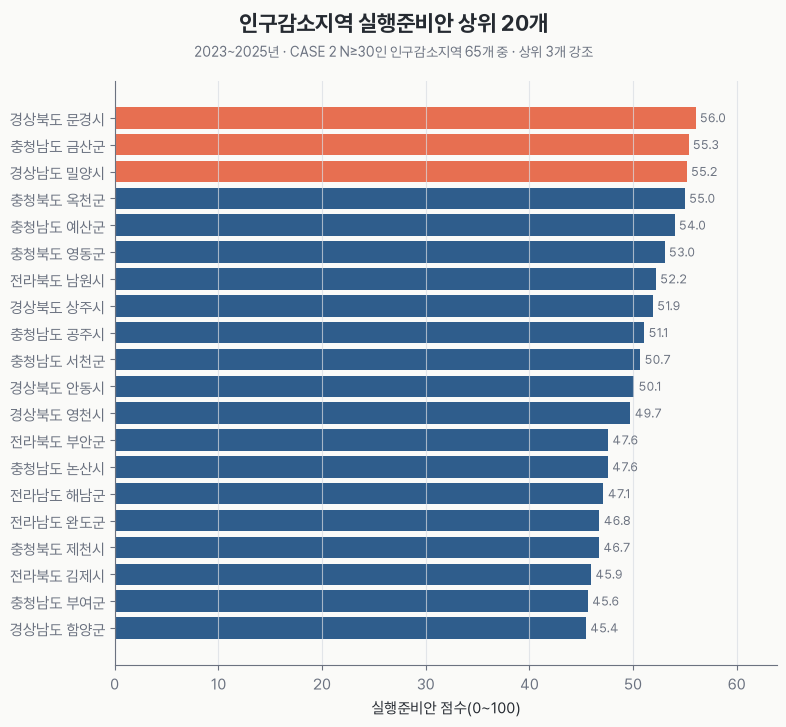

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures\execution_readiness_population_decline_top20.png


In [14]:
apply_plot_style()
execution_top20 = (
    decline_plan_top20.loc[
        decline_plan_top20["점수안"].eq("실행준비안")
    ]
    .sort_values("점수")
    .copy()
)
bar_colors = np.where(
    execution_top20["순위"].le(3),
    COLORS["accent"],
    COLORS["primary"],
)

figure, axis = plt.subplots(figsize=(8, 7.5))
bars = axis.barh(
    execution_top20["지역명"],
    execution_top20["점수"],
    color=bar_colors,
)
axis.bar_label(
    bars,
    labels=[
        f"{value:.1f}"
        for value in execution_top20["점수"]
    ],
    padding=3,
    color=COLORS["neutral"],
    fontsize=9,
)
axis.set_xlim(
    0,
    execution_top20["점수"].max() * 1.14,
)
axis.set_xlabel("실행준비안 점수(0~100)")
axis.set_ylabel("")
axis.grid(axis="x")
figure.suptitle(
    "인구감소지역 실행준비안 상위 20개",
    x=0.5,
    y=0.965,
    ha="center",
)

figure.text(
    0.5,
    0.92,
    (
        f"2023~2025년 · CASE 2 N≥{MIN_CASE2_N}인 "
        "인구감소지역 65개 중 · 상위 3개 강조"
    ),
    ha="center",
    va="top",
    color=COLORS["neutral"],
    fontsize=10,
)

figure.tight_layout(rect=(0, 0, 1, 0.95))
execution_bar_path = (
    FIGURES_DIR
    / "execution_readiness_population_decline_top20.png"
)
figure.savefig(
    execution_bar_path,
    dpi=900,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)
print(f"저장 그림: {execution_bar_path}")

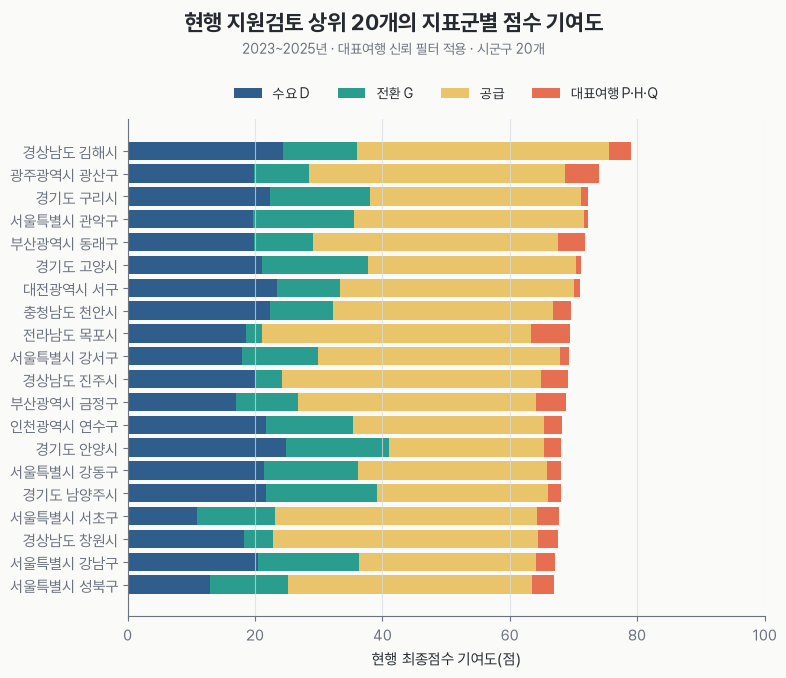

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures\current_top20_indicator_contributions.png


In [15]:
apply_plot_style()
plot_data = current_top20_contributions.sort_values("현행안")
group_colors = [
    COLORS["primary"],
    COLORS["secondary"],
    COLORS["highlight"],
    COLORS["accent"],
]

figure, axis = plt.subplots(figsize=(8, 7))
left = np.zeros(len(plot_data))
for column, color in zip(
    ["수요 D", "전환 G", "공급", "대표여행 P·H·Q"],
    group_colors,
    strict=True,
):
    values = plot_data[column].to_numpy()
    axis.barh(
        plot_data["지역명"],
        values,
        left=left,
        label=column,
        color=color,
    )
    left += values
axis.set_xlim(0, 100)
axis.set_xlabel("현행 최종점수 기여도(점)")
axis.set_ylabel("")
axis.grid(axis="x")
axis.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    frameon=False,
)
figure.suptitle(
    "현행 지원검토 상위 20개의 지표군별 점수 기여도",
    x=0.5,
    y=0.965,
    ha="center",
)
figure.text(
    0.5,
    0.92,
    "2023~2025년 · 대표여행 신뢰 필터 적용 · 시군구 20개",
    ha="center",
    va="top",
    color=COLORS["neutral"],
    fontsize=10,
)
figure.tight_layout(rect=(0, 0, 1, 0.95))
contribution_path = (
    FIGURES_DIR / "current_top20_indicator_contributions.png"
)
figure.savefig(
    contribution_path,
    dpi=900,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)
print(f"저장 그림: {contribution_path}")

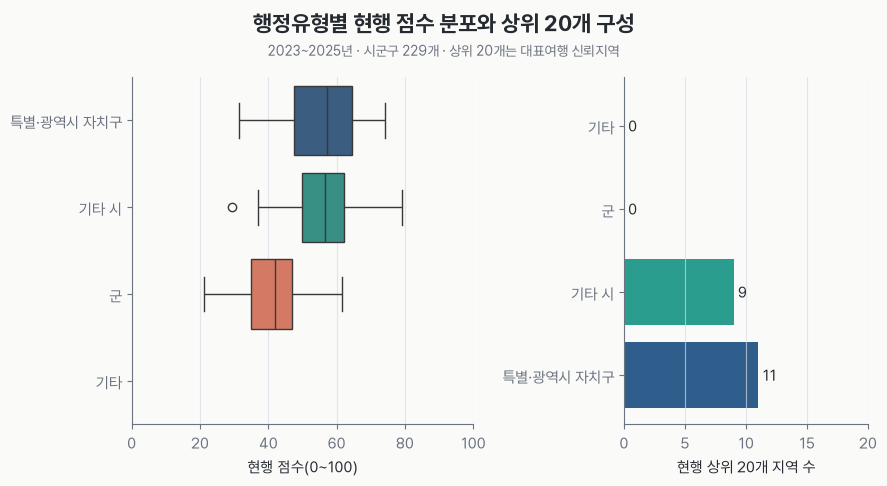

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures\current_score_by_admin_type.png


In [16]:
apply_plot_style()
figure, axes = plt.subplots(
    1,
    2,
    figsize=(9, 5),
    gridspec_kw={"width_ratios": [1.4, 1.0]},
)
sns.boxplot(
    data=current_result,
    x="현행안",
    y="행정유형",
    order=ADMIN_TYPE_ORDER,
    palette=PALETTE[:4],
    ax=axes[0],
)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("현행 점수(0~100)")
axes[0].set_ylabel("")
axes[0].grid(axis="x")

admin_top_plot = (
    admin_score_summary.set_index("행정유형")
    .reindex(ADMIN_TYPE_ORDER)
    .reset_index()
)
bars = axes[1].barh(
    admin_top_plot["행정유형"],
    admin_top_plot["현행상위20_지역수"],
    color=PALETTE[:4],
)
axes[1].bar_label(bars, fmt="%.0f", padding=3)
axes[1].set_xlim(0, TOP_N)
axes[1].set_xlabel("현행 상위 20개 지역 수")
axes[1].set_ylabel("")
axes[1].grid(axis="x")

figure.suptitle(
    "행정유형별 현행 점수 분포와 상위 20개 구성",
    x=0.5,
    y=0.965,
    ha="center",
)
figure.text(
    0.5,
    0.9,
    "2023~2025년 · 시군구 229개 · 상위 20개는 대표여행 신뢰지역",
    ha="center",
    va="top",
    color=COLORS["neutral"],
    fontsize=10,
)
figure.tight_layout(rect=(0, 0, 1, 0.95))
admin_path = FIGURES_DIR / "current_score_by_admin_type.png"
figure.savefig(admin_path, dpi=900, bbox_inches="tight")
plt.show()
plt.close(figure)
print(f"저장 그림: {admin_path}")

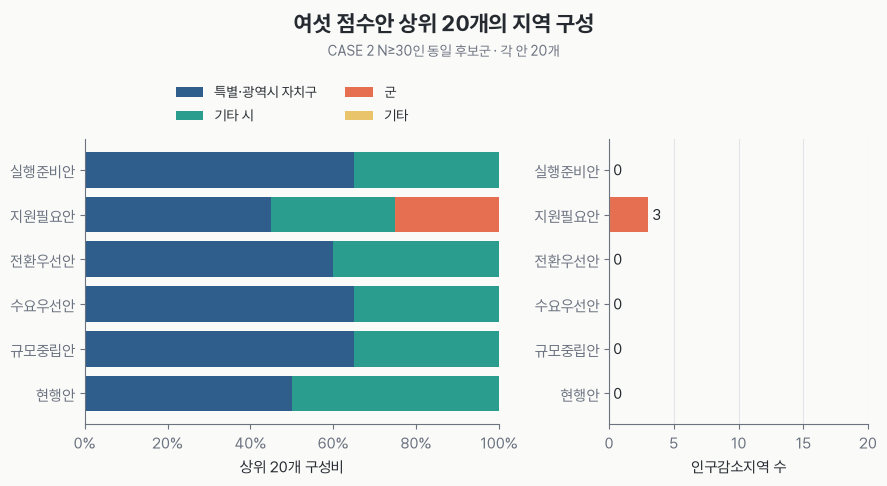

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures\plan_top20_regional_composition.png


In [17]:
apply_plot_style()
admin_plot = (
    admin_composition.pivot(
        index="점수안",
        columns="행정유형",
        values="비중",
    )
    .reindex(index=PLAN_NAMES, columns=ADMIN_TYPE_ORDER)
    .fillna(0.0)
)
decline_plot = (
    decline_composition.set_index("점수안")
    .reindex(PLAN_NAMES)
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(9, 5),
    gridspec_kw={"width_ratios": [1.6, 1.0]},
)
left = np.zeros(len(admin_plot))
for admin_type, color in zip(
    ADMIN_TYPE_ORDER,
    PALETTE[:4],
    strict=True,
):
    axes[0].barh(
        admin_plot.index,
        admin_plot[admin_type],
        left=left,
        label=admin_type,
        color=color,
    )
    left += admin_plot[admin_type].to_numpy()
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("상위 20개 구성비")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
axes[0].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)

bars = axes[1].barh(
    decline_plot.index,
    decline_plot["인구감소지역수"],
    color=COLORS["accent"],
)
axes[1].bar_label(bars, fmt="%.0f", padding=3)
axes[1].set_xlim(0, TOP_N)
axes[1].set_xlabel("인구감소지역 수")
axes[1].set_ylabel("")
axes[1].grid(axis="x")

figure.suptitle(
    "여섯 점수안 상위 20개의 지역 구성",
    x=0.5,
    y=0.965,
    ha="center",
)
figure.text(
    0.5,
    0.9,
    f"CASE 2 N≥{MIN_CASE2_N}인 동일 후보군 · 각 안 20개",
    ha="center",
    va="top",
    color=COLORS["neutral"],
    fontsize=10,
)
figure.tight_layout(rect=(0, 0, 1, 0.95))
composition_path = (
    FIGURES_DIR / "plan_top20_regional_composition.png"
)
figure.savefig(
    composition_path,
    dpi=900,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)
print(f"저장 그림: {composition_path}")

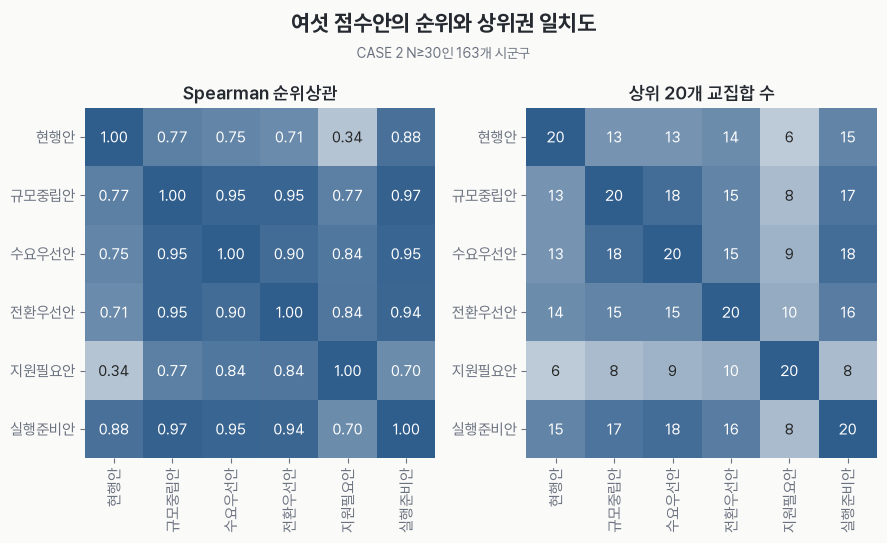

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures\plan_rank_top20_agreement.png


In [18]:
apply_plot_style()
heatmap_cmap = LinearSegmentedColormap.from_list(
    "project_blue",
    [COLORS["background"], COLORS["primary"]],
)
figure, axes = plt.subplots(1, 2, figsize=(9, 5.4))
sns.heatmap(
    rank_correlation,
    vmin=0,
    vmax=1,
    cmap=heatmap_cmap,
    annot=True,
    fmt=".2f",
    square=True,
    cbar=False,
    ax=axes[0],
)
axes[0].set_title("Spearman 순위상관")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    top20_intersection,
    vmin=0,
    vmax=TOP_N,
    cmap=heatmap_cmap,
    annot=True,
    fmt=".0f",
    square=True,
    cbar=False,
    ax=axes[1],
)
axes[1].set_title("상위 20개 교집합 수")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

figure.suptitle(
    "여섯 점수안의 순위와 상위권 일치도",
    x=0.5,
    y=0.965,
    ha="center",
)
figure.text(
    0.5,
    0.9,
    f"CASE 2 N≥{MIN_CASE2_N}인 {eligible_count}개 시군구",
    ha="center",
    va="top",
    color=COLORS["neutral"],
    fontsize=10,
)
figure.tight_layout(rect=(0, 0, 1, 0.95))
agreement_path = FIGURES_DIR / "plan_rank_top20_agreement.png"
figure.savefig(agreement_path, dpi=900, bbox_inches="tight")
plt.show()
plt.close(figure)
print(f"저장 그림: {agreement_path}")

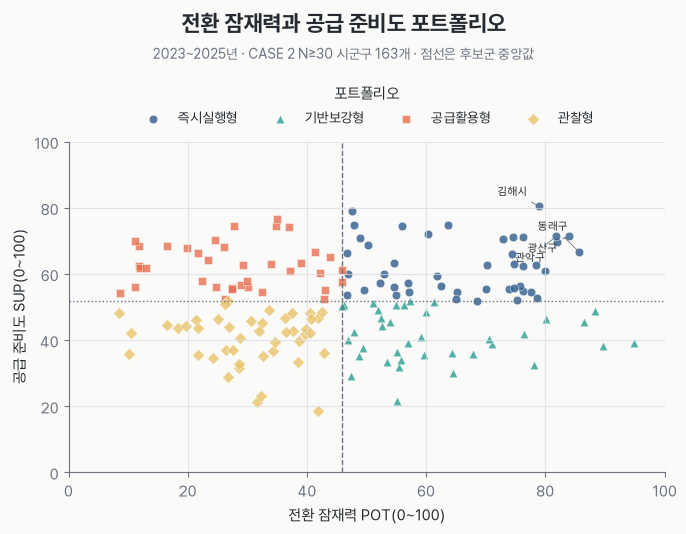

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures\portfolio_all_eligible_regions.png


In [19]:
def plot_portfolio(
    frame: pd.DataFrame,
    title: str,
    subtitle: str,
    output_path: Path,
    label_count: int,
) -> None:
    """POT × SUP 포트폴리오 산점도를 저장한다.

    Args:
        frame: POT, SUP와 포트폴리오 유형을 가진 지역 자료.
        title: 그림 제목.
        subtitle: 그림 부제.
        output_path: 저장할 PNG 경로.
        label_count: 실행준비안 상위 직접 레이블 수.
    """
    apply_plot_style()
    color_map = dict(zip(PORTFOLIO_ORDER, PALETTE[:4], strict=True))
    marker_map = {
        "즉시실행형": "o",
        "기반보강형": "^",
        "공급활용형": "s",
        "관찰형": "D",
    }
    figure, axis = plt.subplots(figsize=(7, 5.5))
    for portfolio_name in PORTFOLIO_ORDER:
        subset = frame.loc[
            frame["포트폴리오유형"].eq(portfolio_name)
        ]
        axis.scatter(
            subset["POT"],
            subset["SUP"],
            label=portfolio_name,
            color=color_map[portfolio_name],
            marker=marker_map[portfolio_name],
            s=38,
            alpha=0.80,
            edgecolor="white",
            linewidth=0.4,
        )
    axis.axvline(
        pot_median,
        color=COLORS["neutral"],
        linestyle="--",
        linewidth=1,
    )
    axis.axhline(
        sup_median,
        color=COLORS["neutral"],
        linestyle=":",
        linewidth=1,
    )
    label_rows = frame.nlargest(label_count, "실행준비안")
    vertical_offsets = [8, -11, 16, -18, 24, -26]
    for position, (_, row) in enumerate(label_rows.iterrows()):
        x_offset = -8 if row["POT"] > 75 else 8
        y_offset = vertical_offsets[
            position % len(vertical_offsets)
        ]
        axis.annotate(
            row["시군구명"],
            (row["POT"], row["SUP"]),
            xytext=(x_offset, y_offset),
            textcoords="offset points",
            ha="right" if x_offset < 0 else "left",
            fontsize=8,
            arrowprops={
                "arrowstyle": "-",
                "color": COLORS["neutral"],
                "linewidth": 0.6,
            },
        )
    axis.set_xlim(0, 100)
    axis.set_ylim(0, 100)
    axis.set_xlabel("전환 잠재력 POT(0~100)")
    axis.set_ylabel("공급 준비도 SUP(0~100)")
    axis.grid()
    axis.legend(
        title="포트폴리오",
        loc="lower center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=4,
        frameon=False,
    )
    figure.suptitle(title, x=0.5, y=0.965, ha="center")
    figure.text(
        0.5,
        0.9,
        subtitle,
        ha="center",
        va="top",
        color=COLORS["neutral"],
        fontsize=10,
    )
    figure.tight_layout(rect=(0, 0, 1, 0.95))
    figure.savefig(output_path, dpi=900, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    print(f"저장 그림: {output_path}")


plot_portfolio(
    regional_scores.loc[eligible_mask],
    "전환 잠재력과 공급 준비도 포트폴리오",
    (
        f"2023~2025년 · CASE 2 N≥{MIN_CASE2_N} "
        f"시군구 {eligible_count}개 · 점선은 후보군 중앙값"
    ),
    FIGURES_DIR / "portfolio_all_eligible_regions.png",
    label_count=4,
)

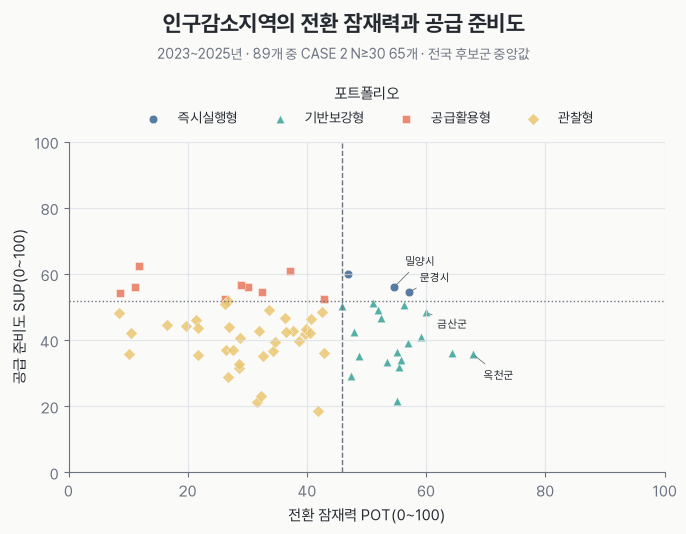

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures\portfolio_population_decline_regions.png


In [20]:
decline_eligible_scores = decline_scores.loc[
    decline_scores["후보자격_CASE2_N30"]
]
plot_portfolio(
    decline_eligible_scores,
    "인구감소지역의 전환 잠재력과 공급 준비도",
    (
        f"2023~2025년 · 89개 중 CASE 2 N≥{MIN_CASE2_N} "
        f"{len(decline_eligible_scores)}개 · 전국 후보군 중앙값"
    ),
    FIGURES_DIR / "portfolio_population_decline_regions.png",
    label_count=4,
)

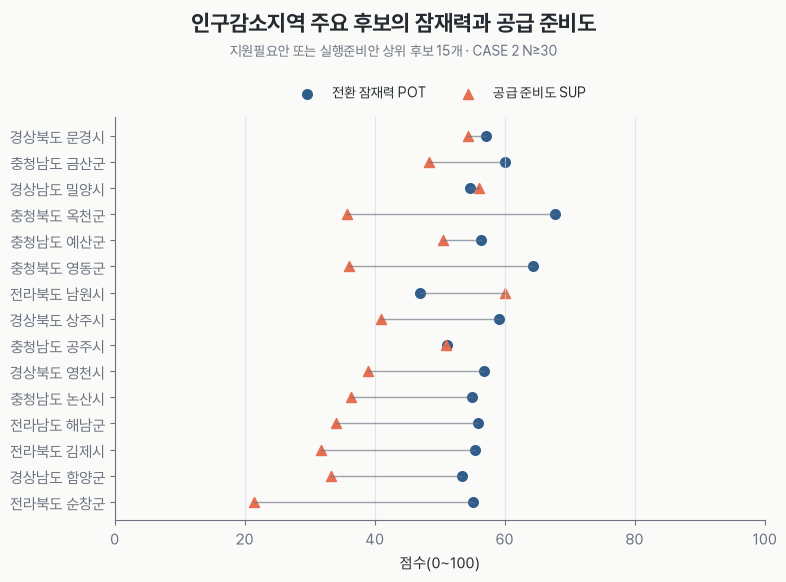

저장 그림: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_연고관광_클러스터별_지역점수_260726_2316\figures\population_decline_potential_supply_dotplot.png


In [21]:
apply_plot_style()
decline_dot_data = (
    decline_scores.loc[
        decline_scores["후보자격_CASE2_N30"]
    ]
    .assign(
        대표순위=lambda frame: frame[
            ["지원필요안_지원후보순위", "실행준비안_지원후보순위"]
        ].min(axis=1)
    )
    .nsmallest(15, "대표순위")
    .sort_values("실행준비안")
)
y_positions = np.arange(len(decline_dot_data))
figure, axis = plt.subplots(figsize=(8, 6))
for position, (_, row) in enumerate(decline_dot_data.iterrows()):
    axis.plot(
        [row["POT"], row["SUP"]],
        [position, position],
        color=COLORS["neutral"],
        linewidth=1,
        alpha=0.65,
    )
axis.scatter(
    decline_dot_data["POT"],
    y_positions,
    label="전환 잠재력 POT",
    color=COLORS["primary"],
    marker="o",
    s=48,
)
axis.scatter(
    decline_dot_data["SUP"],
    y_positions,
    label="공급 준비도 SUP",
    color=COLORS["accent"],
    marker="^",
    s=52,
)
axis.set_yticks(y_positions)
axis.set_yticklabels(decline_dot_data["지역명"])
axis.set_xlim(0, 100)
axis.set_xlabel("점수(0~100)")
axis.set_ylabel("")
axis.grid(axis="x")
axis.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
)
figure.suptitle(
    "인구감소지역 주요 후보의 잠재력과 공급 준비도",
    x=0.5,
    y=0.965,
    ha="center",
)
figure.text(
    0.5,
    0.91,
    (
        "지원필요안 또는 실행준비안 상위 후보 15개 · "
        f"CASE 2 N≥{MIN_CASE2_N}"
    ),
    ha="center",
    va="top",
    color=COLORS["neutral"],
    fontsize=10,
)
figure.tight_layout(rect=(0, 0, 1, 0.95))
decline_dot_path = (
    FIGURES_DIR / "population_decline_potential_supply_dotplot.png"
)
figure.savefig(
    decline_dot_path,
    dpi=900,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)
print(f"저장 그림: {decline_dot_path}")

## 핵심 결과와 해석 한계

아래 실행 요약은 저장된 계산 결과에서 자동 작성한다. 작은 점수 차이는
고정된 서열보다 동점권으로 해석하고, 표본이 작은 지역은 관찰 후보로
분리한다.

In [22]:
nonbaseline_sensitivity = sensitivity_summary.loc[
    sensitivity_summary["시나리오"].ne(
        baseline_sensitivity_name
    )
]
immediate_decline_count = int(
    decline_candidates["포트폴리오유형"]
    .eq("즉시실행형")
    .sum()
)
foundation_decline_count = int(
    decline_candidates["포트폴리오유형"]
    .eq("기반보강형")
    .sum()
)
upper_triangle = np.triu_indices(len(PLAN_NAMES), 1)
minimum_top20_intersection = (
    top20_intersection.to_numpy()[upper_triangle].min()
)
minimum_rank_correlation = (
    rank_correlation.to_numpy()[upper_triangle].min()
)
execution_weight_decline_summary = (
    execution_weight_sensitivity_summary
    .set_index("비교범위")
    .loc["인구감소지역 지원 후보"]
)
summary_text = f"""
### 실행 요약

- 현행 저장표와 독립 재계산의 최대 절대오차는
  **{max_reproduction_error:.2e}점**이며 지원순위 불일치는
  **{(~reproduction['지원순위일치']).sum()}개**다.
- 현행 지원검토 상위 20개 중 인구감소지역은
  **{current_top20['인구감소지역'].sum()}개**, 특별·광역시 자치구는
  **{current_top20['행정유형'].eq('특별·광역시 자치구').sum()}개**다.
- 대안 비교의 공통 후보군은 CASE 2 N≥{MIN_CASE2_N}인
  **{eligible_count}개 시군구**이며, POT·SUP 중앙값은 각각
  **{pot_median:.2f}점**, **{sup_median:.2f}점**이다.
- 여섯 안의 상위 20개 교집합 수 최솟값은
  **{minimum_top20_intersection}개**,
  순위상관 최솟값은
  **{minimum_rank_correlation:.3f}**다.
- 한 요인 민감도에서 실행준비안의 기준 대비 상위 20개 교집합
  최솟값은
  **{nonbaseline_sensitivity['기준_상위20_교집합수'].min()}개**,
  포트폴리오 유형 유지율 최솟값은
  **{nonbaseline_sensitivity['포트폴리오유형_유지율'].min():.1%}**다.
- 실행준비안 가중치를 36%·24%·40%에서 35%·25%·40%로 바꾸면
  인구감소지역 지원 후보의 순위상관은
  **{execution_weight_decline_summary['Spearman_순위상관']:.6f}**,
  상위 20개 교집합은
  **{execution_weight_decline_summary['상위20_교집합수']:.0f}개**,
  최대 순위 변화는
  **{execution_weight_decline_summary['최대_순위절대변화']:.0f}계단**이다.
- 인구감소지역 지원 검토 후보 가운데 즉시실행형은
  **{immediate_decline_count}개**, 기반보강형은
  **{foundation_decline_count}개**다.

### 해석 한계

- 점수는 시설의 존재와 밀도를 나타내며 실제 수용력·품질·운영시간을
  직접 측정하지 않는다.
- CASE 2 지역 표본 수는 군집 구성비의 정확한 유효 표본 수를 대리한다.
- 군집·지표 가중치는 정책 판단을 구조화한 값이며 인과계수가 아니다.
- 인구감소지역 여부는 89개 명칭 목록으로만 사용하며 감소 정도나 지정
  사유를 뜻하지 않는다.
"""
display(Markdown(summary_text))
display(
    decline_candidates.head(20).style.format(
        {
            "POT": "{:.2f}",
            "SUP": "{:.2f}",
            "지원필요안": "{:.2f}",
            "실행준비안": "{:.2f}",
        }
    )
)


### 실행 요약

- 현행 저장표와 독립 재계산의 최대 절대오차는
  **7.11e-15점**이며 지원순위 불일치는
  **0개**다.
- 현행 지원검토 상위 20개 중 인구감소지역은
  **0개**, 특별·광역시 자치구는
  **11개**다.
- 대안 비교의 공통 후보군은 CASE 2 N≥30인
  **163개 시군구**이며, POT·SUP 중앙값은 각각
  **45.87점**, **51.74점**이다.
- 여섯 안의 상위 20개 교집합 수 최솟값은
  **6개**,
  순위상관 최솟값은
  **0.345**다.
- 한 요인 민감도에서 실행준비안의 기준 대비 상위 20개 교집합
  최솟값은
  **17개**,
  포트폴리오 유형 유지율 최솟값은
  **90.2%**다.
- 실행준비안 가중치를 36%·24%·40%에서 35%·25%·40%로 바꾸면
  인구감소지역 지원 후보의 순위상관은
  **0.999432**,
  상위 20개 교집합은
  **20개**,
  최대 순위 변화는
  **2계단**이다.
- 인구감소지역 지원 검토 후보 가운데 즉시실행형은
  **3개**, 기반보강형은
  **18개**다.

### 해석 한계

- 점수는 시설의 존재와 밀도를 나타내며 실제 수용력·품질·운영시간을
  직접 측정하지 않는다.
- CASE 2 지역 표본 수는 군집 구성비의 정확한 유효 표본 수를 대리한다.
- 군집·지표 가중치는 정책 판단을 구조화한 값이며 인과계수가 아니다.
- 인구감소지역 여부는 89개 명칭 목록으로만 사용하며 감소 정도나 지정
  사유를 뜻하지 않는다.


,시도명,시군구명,지역명,case2_trip_n_all_trip_case15,후보구분,포트폴리오유형,POT,SUP,지원필요안,실행준비안,주요_공급군집
0,경상북도,문경시,경상북도 문경시,66,지원 검토 후보,즉시실행형,57.11,54.41,52.51,56.03,숙박 C3
1,경상남도,밀양시,경상남도 밀양시,205,지원 검토 후보,즉시실행형,54.63,56.00,50.38,55.18,숙박 C3
2,전라북도,남원시,전라북도 남원시,102,지원 검토 후보,즉시실행형,46.95,60.08,44.14,52.20,숙박 C3
3,충청남도,금산군,충청남도 금산군,97,지원 검토 후보,기반보강형,60.03,48.33,56.68,55.35,당일 C2
4,충청북도,옥천군,충청북도 옥천군,87,지원 검토 후보,기반보강형,67.79,35.80,66.35,54.99,당일 C2
5,충청남도,예산군,충청남도 예산군,105,지원 검토 후보,기반보강형,56.36,50.47,53.63,54.00,당일 C2
6,충청북도,영동군,충청북도 영동군,45,지원 검토 후보,기반보강형,64.38,36.04,64.21,53.04,숙박 C3
7,경상북도,상주시,경상북도 상주시,53,지원 검토 후보,기반보강형,59.17,41.04,59.08,51.92,숙박 C3
8,충청남도,공주시,충청남도 공주시,206,지원 검토 후보,기반보강형,51.12,51.03,50.26,51.09,당일 C2
9,충청남도,서천군,충청남도 서천군,93,지원 검토 후보,기반보강형,51.89,48.92,51.56,50.70,숙박 C3


In [23]:
from src.notebook_sync import sync_script_from_notebook

sync_script_from_notebook(
    "notebooks/06_Score/"
    "260726_연고관광_클러스터별_지역점수.ipynb"
)

생성 스크립트를 노트북 기준으로 만들었습니다: C:\Users\ilove\OneDrive\Desktop\tourism_poster\script\260726_연고관광_클러스터별_지역점수.py


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/script/260726_연고관광_클러스터별_지역점수.py')